# Experiment: Generalization

Preliminary functions and imports

In [18]:
import os
import numpy as np
import pandas as pd
from time import time
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Reshape


def create_nn_model(input_shape, num_classes):
    model = Sequential([
        # Reshape the input vector to a sequence with one channel
        Reshape((input_shape, 1), input_shape=(input_shape,)),
        
        # Convolutional layers
        Conv1D(64, kernel_size=3, activation='tanh'),
        MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation='tanh'),
        MaxPooling1D(pool_size=2),
        
        # Flatten and Dense layers
        Flatten(),
        Dense(128, activation='tanh'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

pd.set_option('display.max_columns', 100) #replace n with the number of columns you want to see completely
pd.set_option('display.max_rows', 100) #replace n with the number of rows you want to see completely


2025-04-15 09:00:17.001521: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-15 09:00:17.012826: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744700417.025268  276950 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744700417.028905  276950 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744700417.038578  276950 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Load data files

In [19]:
path = os.path.join('/mnt/AI-DATA/alara/CiberIA_O1/Data')

print("Reading data...")
df_2017 = pd.read_csv(os.path.join(path, 'CIC-IDS2017.csv'))

le_2017 = LabelEncoder()
df_2017['Attack Number'] = le_2017.fit_transform(df_2017['Attack Type'])

print("CIC-IDS2017 data loaded.")

Reading data...
CIC-IDS2017 data loaded.


In [20]:
print("Reading data...")
df_2018 = pd.read_csv(os.path.join(path, 'CIC-IDS2018.csv'))

attack_map = {
    'Benign': 'BENIGN',
    'DDOS attack-HOIC': 'DDoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DoS attacks-Hulk': 'DoS',
    'Bot': 'Bot',
    'Infilteration': 'Infiltration',
    'SSH-Bruteforce': 'Brute Force',
    'DoS attacks-GoldenEye': 'DoS',
    'FTP-BruteForce': 'Brute Force',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'Brute Force -Web': 'Brute Force',
    'Brute Force -XSS': 'Brute Force',
    'SQL Injection': 'Injection'
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df_2018['Attack Type'] = df_2018['Label'].map(attack_map)
df_2018.drop('Label', axis = 1, inplace = True)

print("Encoding attack types...")
le_2018 = LabelEncoder()
df_2018['Attack Number'] = le_2018.fit_transform(df_2018['Attack Type'])

# modify column names. replace Cnt with Count, Pkts with Packets and Byts with Bytes
df_2018.columns = df_2018.columns.str.replace('Cnt', 'Count')
df_2018.columns = df_2018.columns.str.replace('Pkts', 'Packets')
df_2018.columns = df_2018.columns.str.replace('Pkt', 'Packet')
df_2018.columns = df_2018.columns.str.replace('Byts', 'Bytes')

print("CIC-IDS2018 data loaded.")

Reading data...
Encoding attack types...
CIC-IDS2018 data loaded.


In [21]:
print("Reading data...")
df_2019 = pd.read_csv(os.path.join(path, 'CIC-DDoS2019.csv'))

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df_2019['Attack Type'] = df_2019['Label']
df_2019.drop('Label', axis = 1, inplace = True)

le_2019 = LabelEncoder()
df_2019['Attack Number'] = le_2019.fit_transform(df_2019['Attack Type'])

print("CIC-IDS2019 data loaded.")

Reading data...


/tmp/ipykernel_276950/2044327925.py:2: DtypeWarning: Columns (77) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2019 = pd.read_csv(os.path.join(path, 'CIC-DDoS2019.csv'))


CIC-IDS2019 data loaded.


In [22]:
print("Reading data...")
df_unsw = pd.read_csv(os.path.join(path, 'UNSW-NB15.csv'))

#change 'Benign' to 'BENIGN'
df_unsw['Label'] = df_unsw['Label'].replace('Benign', 'BENIGN')

df_unsw['Attack Type'] = df_unsw['Label']
df_unsw.drop('Label', axis = 1, inplace = True)

le_unsw = LabelEncoder()
df_unsw['Attack Number'] = le_unsw.fit_transform(df_unsw['Attack Type'])

print("UNSW-NB15 data loaded.")

Reading data...
UNSW-NB15 data loaded.


In [57]:
# list columns orderer aklpahbetically
columns_cicids2017 = sorted(df_2017.columns)
columns_cicids2018 = sorted(df_2018.columns)
columns_cicids2019 = sorted(df_2019.columns)
columns_unsw = sorted(df_unsw.columns)
# create a df with the columns names, fill with NaN so that all columns have the same length
max_length = max(len(columns_cicids2017), len(columns_cicids2018), len(columns_cicids2019), len(columns_unsw))
columns_cicids2017 += [np.nan] * (max_length - len(columns_cicids2017))
columns_cicids2018 += [np.nan] * (max_length - len(columns_cicids2018))
columns_cicids2019 += [np.nan] * (max_length - len(columns_cicids2019))
columns_unsw += [np.nan] * (max_length - len(columns_unsw))
# find the subset of columns that are in all dataframes
common_columns = set(df_2017.columns) & set(df_2018.columns) & set(df_2019.columns) & set(df_unsw.columns)
common_columns = sorted(common_columns)
common_columns_na = list(common_columns)
common_columns_na += [np.nan] * (max_length - len(common_columns))
df_columns = pd.DataFrame({
    'CICIDS2017': columns_cicids2017,
    'CICIDS2018': columns_cicids2018,
    'CICIDS2019': columns_cicids2019,
    'UNSW-NB15': columns_unsw,
    'Common': common_columns_na
})
# print table using IPhyton
print("Data columns:")
from IPython.display import display
display(df_columns)



Data columns:


,CICIDS2017,CICIDS2018,CICIDS2019,UNSW-NB15,Common
0,ACK Flag Count,ACK Flag Count,ACK Flag Count,ACK Flag Count,ACK Flag Count
1,Active Max,Active Max,Active Max,Active Max,Active Max
2,Active Mean,Active Mean,Active Mean,Active Mean,Active Mean
3,Active Min,Active Min,Active Min,Active Min,Active Min
4,Active Std,Active Std,Active Std,Active Std,Active Std
5,Attack Number,Attack Number,Attack Number,Attack Number,Attack Number
6,Attack Type,Attack Type,Attack Type,Attack Type,Attack Type
7,Bwd IAT Max,Bwd IAT Max,Bwd IAT Max,Bwd IAT Max,Bwd IAT Max
8,Bwd IAT Mean,Bwd IAT Mean,Bwd IAT Mean,Bwd IAT Mean,Bwd IAT Mean
9,Bwd IAT Min,Bwd IAT Min,Bwd IAT Min,Bwd IAT Min,Bwd IAT Min


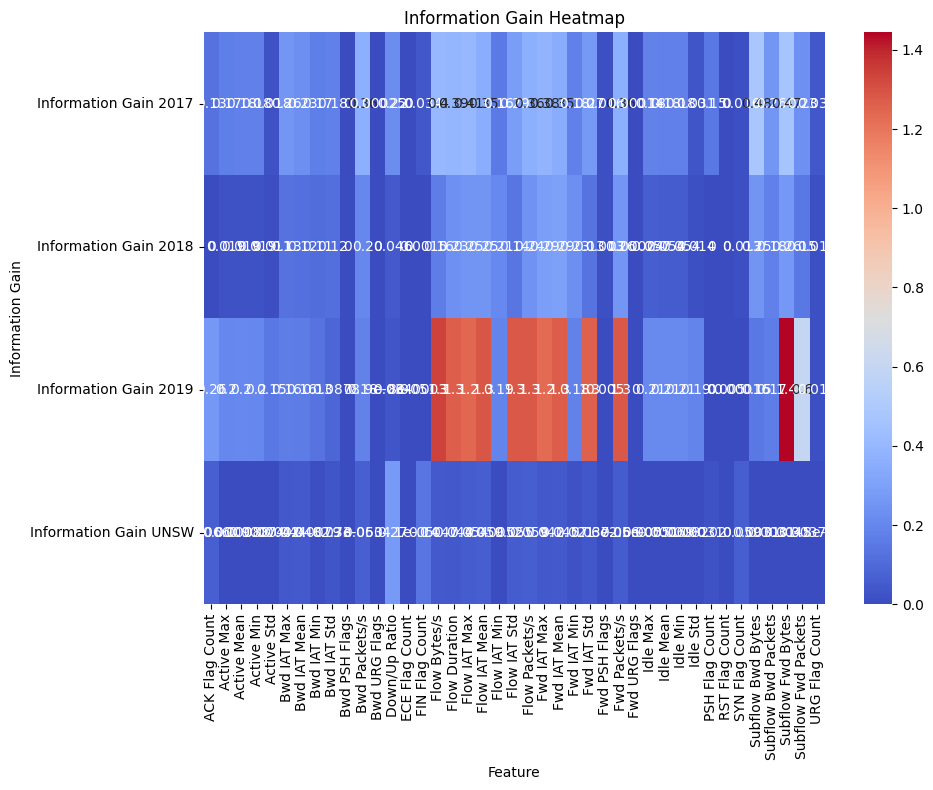

In [ ]:
# Select only the common columns
df_2017 = df_2017[common_columns]
df_2018 = df_2018[common_columns]
df_2019 = df_2019[common_columns]
df_unsw = df_unsw[common_columns]

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

X_2017 = df_2017.drop(columns=['Attack Number', 'Attack Type'])
y_2017 = df_2017['Attack Number']
X_2018 = df_2018.drop(columns=['Attack Number', 'Attack Type'])
y_2018 = df_2018['Attack Number']
X_2019 = df_2019.drop(columns=['Attack Number', 'Attack Type'])
y_2019 = df_2019['Attack Number']
X_unsw = df_unsw.drop(columns=['Attack Number', 'Attack Type'])
y_unsw = df_unsw['Attack Number']

# Compute information gain for each dataset
info_gain_2017 = mutual_info_classif(X_2017, y_2017, random_state=42)
info_gain_2018 = mutual_info_classif(X_2018, y_2018, random_state=42)
info_gain_2019 = mutual_info_classif(X_2019, y_2019, random_state=42)
info_gain_unsw = mutual_info_classif(X_unsw, y_unsw, random_state=42)

# Create a DataFrame with information gain
info_gain_df_2017 = pd.DataFrame({'Feature': X_2017.columns, 'Information Gain': info_gain_2017})
info_gain_df_2018 = pd.DataFrame({'Feature': X_2018.columns, 'Information Gain': info_gain_2018})
info_gain_df_2019 = pd.DataFrame({'Feature': X_2019.columns, 'Information Gain': info_gain_2019})
info_gain_df_unsw = pd.DataFrame({'Feature': X_unsw.columns, 'Information Gain': info_gain_unsw})

# Sort the DataFrame by feature alphabetically
info_gain_df_2017 = info_gain_df_2017.sort_values(by='Feature')
info_gain_df_2018 = info_gain_df_2018.sort_values(by='Feature')
info_gain_df_2019 = info_gain_df_2019.sort_values(by='Feature')
info_gain_df_unsw = info_gain_df_unsw.sort_values(by='Feature')

# Combine all columns
info_gain_combined = pd.merge(info_gain_df_2017, info_gain_df_2018, on='Feature', how='outer', suffixes=('_2017', '_2018'))
info_gain_combined = pd.merge(info_gain_combined, info_gain_df_2019, on='Feature', how='outer', suffixes=('', '_2019'))
info_gain_combined = pd.merge(info_gain_combined, info_gain_df_unsw, on='Feature', how='outer', suffixes=('', '_unsw'))

In [32]:
# Rename columns
info_gain_combined.columns = ['Feature', 'CIC-IDS2017', 'CIC-IDS2018', 'CIC-DDoS2019', 'UNSW-NB15']

#save csv
info_gain_combined.to_csv(os.path.join(path, 'info_gain_combined.csv'), index=False)

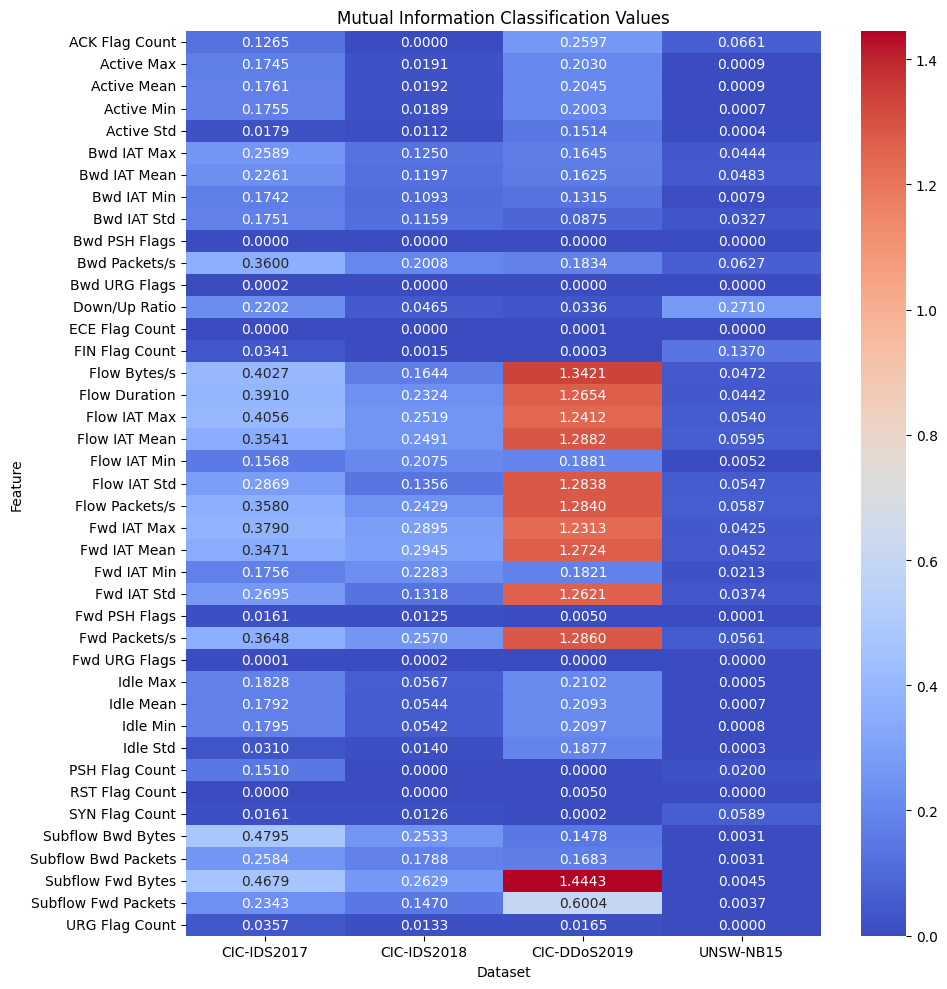

In [ ]:
# create a heatmap of the information gain
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
sns.heatmap(info_gain_combined.set_index('Feature'), annot=True, fmt=".4f", cmap='RdB', cbar=True)
plt.title('Mutual Information Classification Values')
plt.xlabel('Dataset')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('mutual_info_classification.png', dpi=500)

# save 500dpi


In [50]:
#for each dataset, list attacks
# create a df
df_attacks_2017 = pd.DataFrame(df_2017['Attack Type'].value_counts())
df_attacks_2017.reset_index(inplace=True)
df_attacks_2017.columns = ['Attack Type', 'Count']
df_attacks_2017['Dataset'] = 'CIC-IDS2017'
df_attacks_2018 = pd.DataFrame(df_2018['Attack Type'].value_counts())
df_attacks_2018.reset_index(inplace=True)
df_attacks_2018.columns = ['Attack Type', 'Count']
df_attacks_2018['Dataset'] = 'CIC-IDS2018'
df_attacks_2019 = pd.DataFrame(df_2019['Attack Type'].value_counts())
df_attacks_2019.reset_index(inplace=True)
df_attacks_2019.columns = ['Attack Type', 'Count']
df_attacks_2019['Dataset'] = 'CIC-DDoS2019'
df_attacks_unsw = pd.DataFrame(df_unsw['Attack Type'].value_counts())
df_attacks_unsw.reset_index(inplace=True)
df_attacks_unsw.columns = ['Attack Type', 'Count']
df_attacks_unsw['Dataset'] = 'UNSW-NB15'

# combine all dataframes
# Create a list of unique attack types across all datasets
unique_attacks = pd.concat([df_attacks_2017, df_attacks_2018, df_attacks_2019, df_attacks_unsw])['Attack Type'].unique()

# Initialize a new DataFrame with unique attacks as rows
df_summary = pd.DataFrame({'Attack Type': unique_attacks})

# Add columns for each dataset's count and total
df_summary['CIC-IDS2017 Count'] = df_summary['Attack Type'].map(df_attacks_2017.set_index('Attack Type')['Count']).fillna(0).astype(int)
df_summary['CIC-IDS2018 Count'] = df_summary['Attack Type'].map(df_attacks_2018.set_index('Attack Type')['Count']).fillna(0).astype(int)
df_summary['CIC-DDoS2019 Count'] = df_summary['Attack Type'].map(df_attacks_2019.set_index('Attack Type')['Count']).fillna(0).astype(int)
df_summary['UNSW-NB15 Count'] = df_summary['Attack Type'].map(df_attacks_unsw.set_index('Attack Type')['Count']).fillna(0).astype(int)

# Add a total column summing all counts
df_summary['Total Count'] = df_summary[['CIC-IDS2017 Count', 'CIC-IDS2018 Count', 'CIC-DDoS2019 Count', 'UNSW-NB15 Count']].sum(axis=1)
#order by total count
df_summary = df_summary.sort_values(by='Total Count', ascending=False)

# add a column with for each dataset with the percentage of the total
df_summary['CIC-IDS2017 Percentage'] = (df_summary['CIC-IDS2017 Count'] / df_summary['Total Count']) * 100
df_summary['CIC-IDS2018 Percentage'] = (df_summary['CIC-IDS2018 Count'] / df_summary['Total Count']) * 100
df_summary['CIC-DDoS2019 Percentage'] = (df_summary['CIC-DDoS2019 Count'] / df_summary['Total Count']) * 100
df_summary['UNSW-NB15 Percentage'] = (df_summary['UNSW-NB15 Count'] / df_summary['Total Count']) * 100

display(df_summary)


,Attack Type,CIC-IDS2017 Count,CIC-IDS2018 Count,CIC-DDoS2019 Count,UNSW-NB15 Count,Total Count,CIC-IDS2017 Percentage,CIC-IDS2018 Percentage,CIC-DDoS2019 Percentage,UNSW-NB15 Percentage
0,BENIGN,2272895,13445498,96546,3390752,19205691,11.834487,70.007885,0.502695,17.654934
10,TFTP,0,0,4578741,0,4578741,0.000000,0.000000,100.000000,0.000000
3,DDoS,128027,1246366,0,0,1374393,9.315167,90.684833,0.000000,0.000000
11,UDP,0,0,1343167,0,1343167,0.000000,0.000000,100.000000,0.000000
12,DrDoS_UDP,0,0,1127468,0,1127468,0.000000,0.000000,100.000000,0.000000
13,DrDoS_NTP,0,0,1116430,0,1116430,0.000000,0.000000,100.000000,0.000000
14,DrDoS_SSDP,0,0,925675,0,925675,0.000000,0.000000,100.000000,0.000000
1,DoS,252660,506075,0,4467,763202,33.105259,66.309444,0.000000,0.585297
15,Syn,0,0,689387,0,689387,0.000000,0.000000,100.000000,0.000000
16,MSSQL,0,0,290470,0,290470,0.000000,0.000000,100.000000,0.000000


In [32]:
# Select only the common columns
df_2017 = df_2017[common_columns]
df_2018 = df_2018[common_columns]
df_2019 = df_2019[common_columns]
df_unsw = df_unsw[common_columns]

# create coombinations of all dataframes
df_2017_2018 = pd.concat([df_2017, df_2018], ignore_index=True)
df_2017_2019 = pd.concat([df_2017, df_2019], ignore_index=True)
df_2017_unsw = pd.concat([df_2017, df_unsw], ignore_index=True)
df_2018_2019 = pd.concat([df_2018, df_2019], ignore_index=True)
df_2018_unsw = pd.concat([df_2018, df_unsw], ignore_index=True)

df_2017_2018_2019 = pd.concat([df_2017, df_2018, df_2019], ignore_index=True)
df_2017_2018_unsw = pd.concat([df_2017, df_2018, df_unsw], ignore_index=True)
df_2017_2019_unsw = pd.concat([df_2017, df_2019, df_unsw], ignore_index=True)
df_2018_2019_unsw = pd.concat([df_2018, df_2019, df_unsw], ignore_index=True)

df_2017_2018_2019_unsw = pd.concat([df_2017, df_2018, df_2019, df_unsw], ignore_index=True)

base_dataframe = {
    'CICIDS2017': df_2017,
    'CICIDS2018': df_2018,
    'CICIDS2019': df_2019,
    'UNSW-NB15': df_unsw
}

# combine in a dictionary to iterate over
dataframes = {
    'CICIDS2017': df_2017,
    'CICIDS2018': df_2018,
    'CICDDoS2019': df_2019,
    'UNSW-NB15': df_unsw,
    'CICIDS2017_CICIDS2018': df_2017_2018,
    'CICIDS2017_CICDDoS2019': df_2017_2019,
    'CICIDS2017_UNSW-NB15': df_2017_unsw,
    'CICIDS2018_CICDDoS2019': df_2018_2019,
    'CICIDS2018_UNSW-NB15': df_2018_unsw,
    'CICIDS2017_CICIDS2018_CICDDoS2019': df_2017_2018_2019,
    'CICIDS2017_CICIDS2018_UNSW-NB15': df_2017_2018_unsw,
    'CICIDS2017_CICDDoS2019_UNSW-NB15': df_2017_2019_unsw,
    'CICIDS2018_CICDDoS2019_UNSW-NB15': df_2018_2019_unsw,
    'CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15': df_2017_2018_2019_unsw
}

In [33]:
import pandas as pd
import numpy as np

summary_data = []

for name, df in dataframes.items():
    total_samples = len(df)
    
    # Máscaras
    attack_mask = ~df['Attack Type'].isin(['BENIGN', 'Normal'])
    benign_mask = df['Attack Type'].isin(['BENIGN', 'Normal'])

    # Conteos
    num_attack = attack_mask.sum()
    num_benign = benign_mask.sum()
    
    attack_ratio = num_attack / total_samples if total_samples else 0
    benign_ratio = num_benign / total_samples if total_samples else 0

    # Tipos de ataque
    attack_types_count = df.loc[attack_mask, 'Attack Type'].nunique()

    # Entropía de clases (benign + attack types)
    class_probs = df['Attack Type'].value_counts(normalize=True)
    entropy = -np.sum(class_probs * np.log2(class_probs))

    summary_data.append({
        'Dataset': name,
        'Total Samples': f"{total_samples}",
        'Attack Instances': f"{num_attack} ({attack_ratio:.2%})",
        'Benign Instances': f"{num_benign} ({benign_ratio:.2%})",
        'Distinct Attack Types': attack_types_count,
        'Class Entropy': round(entropy, 4)
    })

# Crear el DataFrame resumen
summary_df = pd.DataFrame(summary_data)

# Mostrarlo bonito
display(summary_df)


,Dataset,Total Samples,Attack Instances,Benign Instances,Distinct Attack Types,Class Entropy
0,CICIDS2017,2830540,557645 (19.70%),2272895 (80.30%),8,1.0537
1,CICIDS2018,15799748,2354250 (14.90%),13445498 (85.10%),6,0.8840
2,CICDDoS2019,10850095,10753549 (99.11%),96546 (0.89%),18,2.7393
3,UNSW-NB15,3480335,89583 (2.57%),3390752 (97.43%),9,0.2284
4,CICIDS2017_CICIDS2018,18630288,2911895 (15.63%),15718393 (84.37%),9,0.9464
5,CICIDS2017_CICDDoS2019,13680635,11311194 (82.68%),2369441 (17.32%),26,3.0835
6,CICIDS2017_UNSW-NB15,6310875,647228 (10.26%),5663647 (89.74%),16,0.7137
7,CICIDS2018_CICDDoS2019,26649843,13107799 (49.19%),13542044 (50.81%),24,2.5833
8,CICIDS2018_UNSW-NB15,19280083,2443833 (12.68%),16836250 (87.32%),14,0.8121
9,CICIDS2017_CICIDS2018_CICDDoS2019,29480383,13665444 (46.35%),15814939 (53.65%),27,2.5267


In [58]:
import os
import warnings
import numpy as np
import pandas as pd
from time import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgbm
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Reshape
from sklearn.svm import LinearSVC

def evaluate_model(model, X_train, X_test, y_train, y_test, key, is_neural=False):
    start_time = time()
    
    # Create label encoder for models that require numeric labels
    le = LabelEncoder()
    if isinstance(model, (xgb.XGBClassifier, SVC)):
        y_train_encoded = le.fit_transform(y_train)
        y_test_encoded = le.transform(y_test)
    else:
        y_train_encoded = y_train
        y_test_encoded = y_test
    
    if is_neural:
        y_train_cat = to_categorical(pd.Categorical(y_train).codes)
        y_test_cat = to_categorical(pd.Categorical(y_test).codes)
        
        model.fit(X_train, y_train_cat,
                 epochs=10,
                 batch_size=64,
                 validation_split=0.3,
                 verbose=0)
        
        y_pred_prob = model.predict(X_test)
        y_pred = np.unique(y_test)[np.argmax(y_pred_prob, axis=1)]
    else:
        model.fit(X_train, y_train_encoded)
        y_pred_encoded = model.predict(X_test)
        
        # Convert predictions back to original labels if needed
        if isinstance(model, (xgb.XGBClassifier, SVC)):
            y_pred = le.inverse_transform(y_pred_encoded)
        else:
            y_pred = y_pred_encoded
    
    exec_time = time() - start_time
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    # get classification report and confusion matrix and save to a file
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(f'/home/alara/CiberIA_O1/results/{key}_{model.__class__.__name__}_classification_report.csv')

    # Save confusion matrix as table
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=np.unique(y_test), columns=np.unique(y_test))
    cm_df.to_csv(f'/home/alara/CiberIA_O1/results/{key}_{model.__class__.__name__}_confusion_matrix.csv')

    # Save confusion matrix plot
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f'/home/alara/CiberIA_O1/results/{key}_{model.__class__.__name__}_confusion_matrix.png', dpi=500)
    plt.close()
    
    return accuracy, f1, exec_time

Datasets:   0%|                                                              | 0/14 [00:00<?, ?it/s]

Processing CICIDS2017...
Information retained: 98.78%
Training Random Forest...


Datasets:   0%|                                                              | 0/14 [00:05<?, ?it/s]


KeyboardInterrupt: 

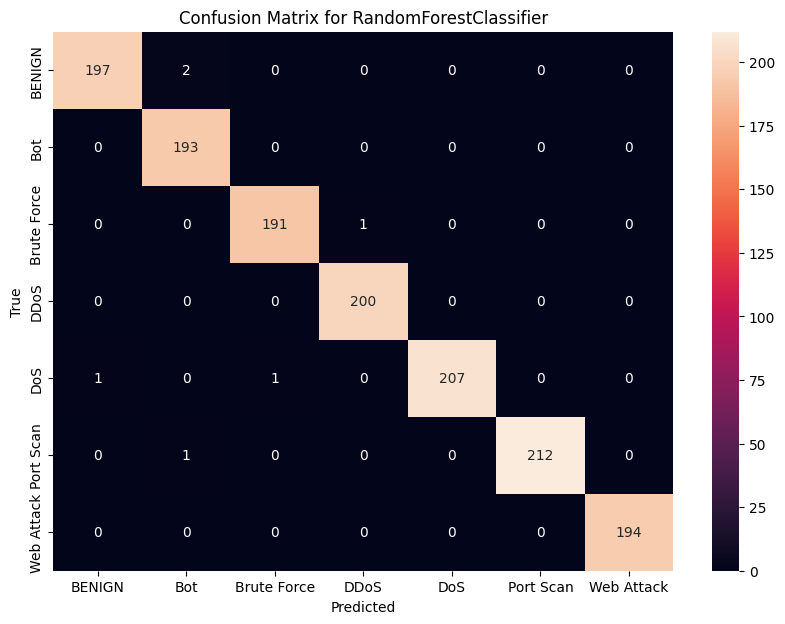

In [59]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import tqdm
from imblearn.over_sampling import SMOTE

results = {}
samples_per_class = 1000
model_dict = {}

for key, df in tqdm.tqdm(dataframes.items(), desc="Datasets"):
    print(f"Processing {key}...")

    le = LabelEncoder()
    df['Attack Number'] = le.fit_transform(df['Attack Type'])

    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
    new_memory_usage = df.memory_usage().sum() / 1024 ** 2

    data = df.copy()

    attacks = data['Attack Type']
    data = data.select_dtypes(include=['float32', 'int32'])

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(data)

    size = len(data.columns) // 2
    pca = PCA(n_components=size)
    transformed_features = pca.fit_transform(scaled_features)
    print(f'Information retained: {sum(pca.explained_variance_ratio_):.2%}')
    new_data_pca = pd.DataFrame(transformed_features, columns=[f'PC{i+1}' for i in range(size)])
    new_data_pca['Attack Type'] = attacks.values

    class_counts = new_data_pca['Attack Type'].value_counts()
    selected_classes = class_counts[class_counts > 1950]
    class_names = selected_classes.index
    selected = new_data_pca[new_data_pca['Attack Type'].isin(class_names)]
    
    dfs = []
    for name in class_names:
        df_class = selected[selected['Attack Type'] == name]
        if len(df_class) > 1950:
            df_class = df_class.sample(n=samples_per_class, replace=True, random_state=0)
        dfs.append(df_class)
    
    balanced_df = pd.concat(dfs, ignore_index=True)
    X = balanced_df.drop('Attack Type', axis=1)
    y = balanced_df['Attack Type']
    smote = SMOTE(sampling_strategy='auto', random_state=0)
    X_upsampled, y_upsampled = smote.fit_resample(X, y)
    balanced_data = pd.DataFrame(X_upsampled)
    balanced_data['Attack Type'] = y_upsampled
    balanced_data = balanced_data.sample(frac=1)
    X_train, X_test, y_train, y_test = train_test_split(balanced_data.drop('Attack Type', axis=1), balanced_data['Attack Type'], test_size=0.2, random_state=42)

    # 1. Random Forest
    print("Training Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=85)
    rf_acc, rf_f1, rf_time = evaluate_model(rf_model, X_train, X_test, y_train, y_test, key)
    results[f'RF_{key}'] = (rf_acc, rf_f1, rf_time)
    model_dict[f'RF_{key}'] = rf_model
    
    # 2. k-NN
    print("Training k-NN...")
    knn_model = KNeighborsClassifier(n_neighbors=len(np.unique(y_train)), n_jobs=-1)
    knn_acc, knn_f1, knn_time = evaluate_model(knn_model, X_train, X_test, y_train, y_test, key)
    results[f'k-NN_{key}'] = (knn_acc, knn_f1, knn_time)
    model_dict[f'k-NN_{key}'] = knn_model
    
    # 3. LGBM
    print("Training LGBM...")
    lgbm_model = lgbm.LGBMClassifier(n_estimators=100, random_state=85, verbosity=-1)
    lgbm_acc, lgbm_f1, lgbm_time = evaluate_model(lgbm_model, X_train, X_test, y_train, y_test, key)
    results[f'LGBM_{key}'] = (lgbm_acc, lgbm_f1, lgbm_time)
    model_dict[f'LGBM_{key}'] = lgbm_model
        
    # 4. Neural Network
    print("Training Neural Network...")
    nn_model = create_nn_model(X_train.shape[1], len(np.unique(y_train)))
    nn_acc, nn_f1, nn_time = evaluate_model(nn_model, X_train, X_test, y_train, y_test,key, is_neural=True)
    results[f'NN_{key}'] = (nn_acc, nn_f1, nn_time)
    model_dict[f'NN_{key}'] = nn_model

    # 5. XGBoost
    print("Training XGBoost...")
    xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=85)
    xgb_acc, xgb_f1, xgb_time = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, key)
    results[f'XGBoost_{key}'] = (xgb_acc, xgb_f1, xgb_time)
    model_dict[f'XGBoost_{key}'] = xgb_model

    print("Finished processing", key)

In [20]:
#save results to csv
results_df = pd.DataFrame(results, index=['Accuracy', 'F1 Score', 'Execution Time']).T
results_df.columns = ['Accuracy', 'F1 Score', 'Execution Time']
results_df.index.name = 'Model'
results_df.to_csv('/home/alara/CiberIA_O1/results/combined_results.csv', index=True)

# save the model dictionary into a file
import pickle
with open('/home/alara/CiberIA_O1/results/model_dict.pkl', 'wb') as f:
    pickle.dump(model_dict, f)

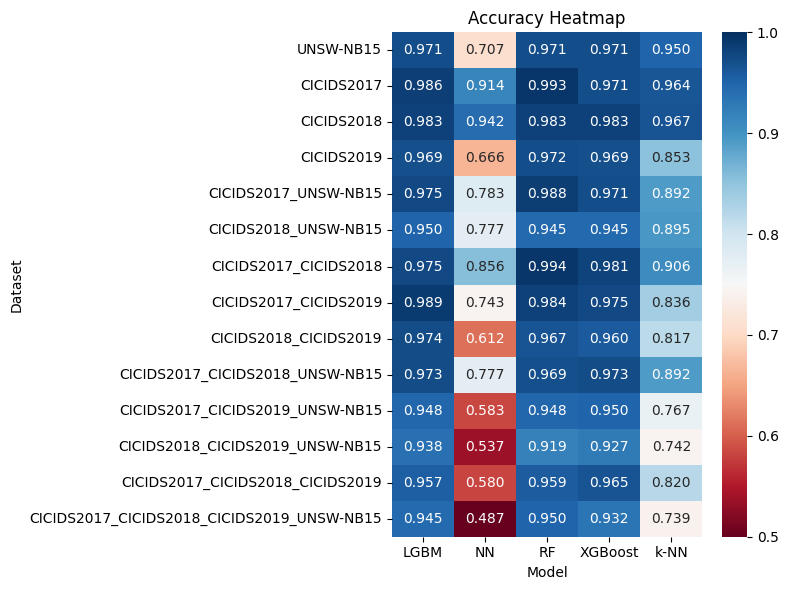

In [12]:
# Load results from CSV
results_df = pd.read_csv('/home/alara/CiberIA_O1/results/combined_results.csv')

results_df.reset_index(inplace=True)

# Extract method and dataset
results_df['Method'] = results_df['Model'].apply(lambda x: x.split('_')[0])
results_df['Dataset'] = results_df['Model'].apply(lambda x: '_'.join(x.split('_')[1:]))

# Pivot table
heatmap_df = results_df.pivot(index='Dataset', columns='Method', values='Accuracy')

# Sort the index by the length of the dataset name
heatmap_df = heatmap_df.loc[sorted(heatmap_df.index, key=len)]

# Plot
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="RdBu", vmin=0.5, vmax=1)
plt.title("Accuracy Heatmap")
plt.ylabel("Dataset")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

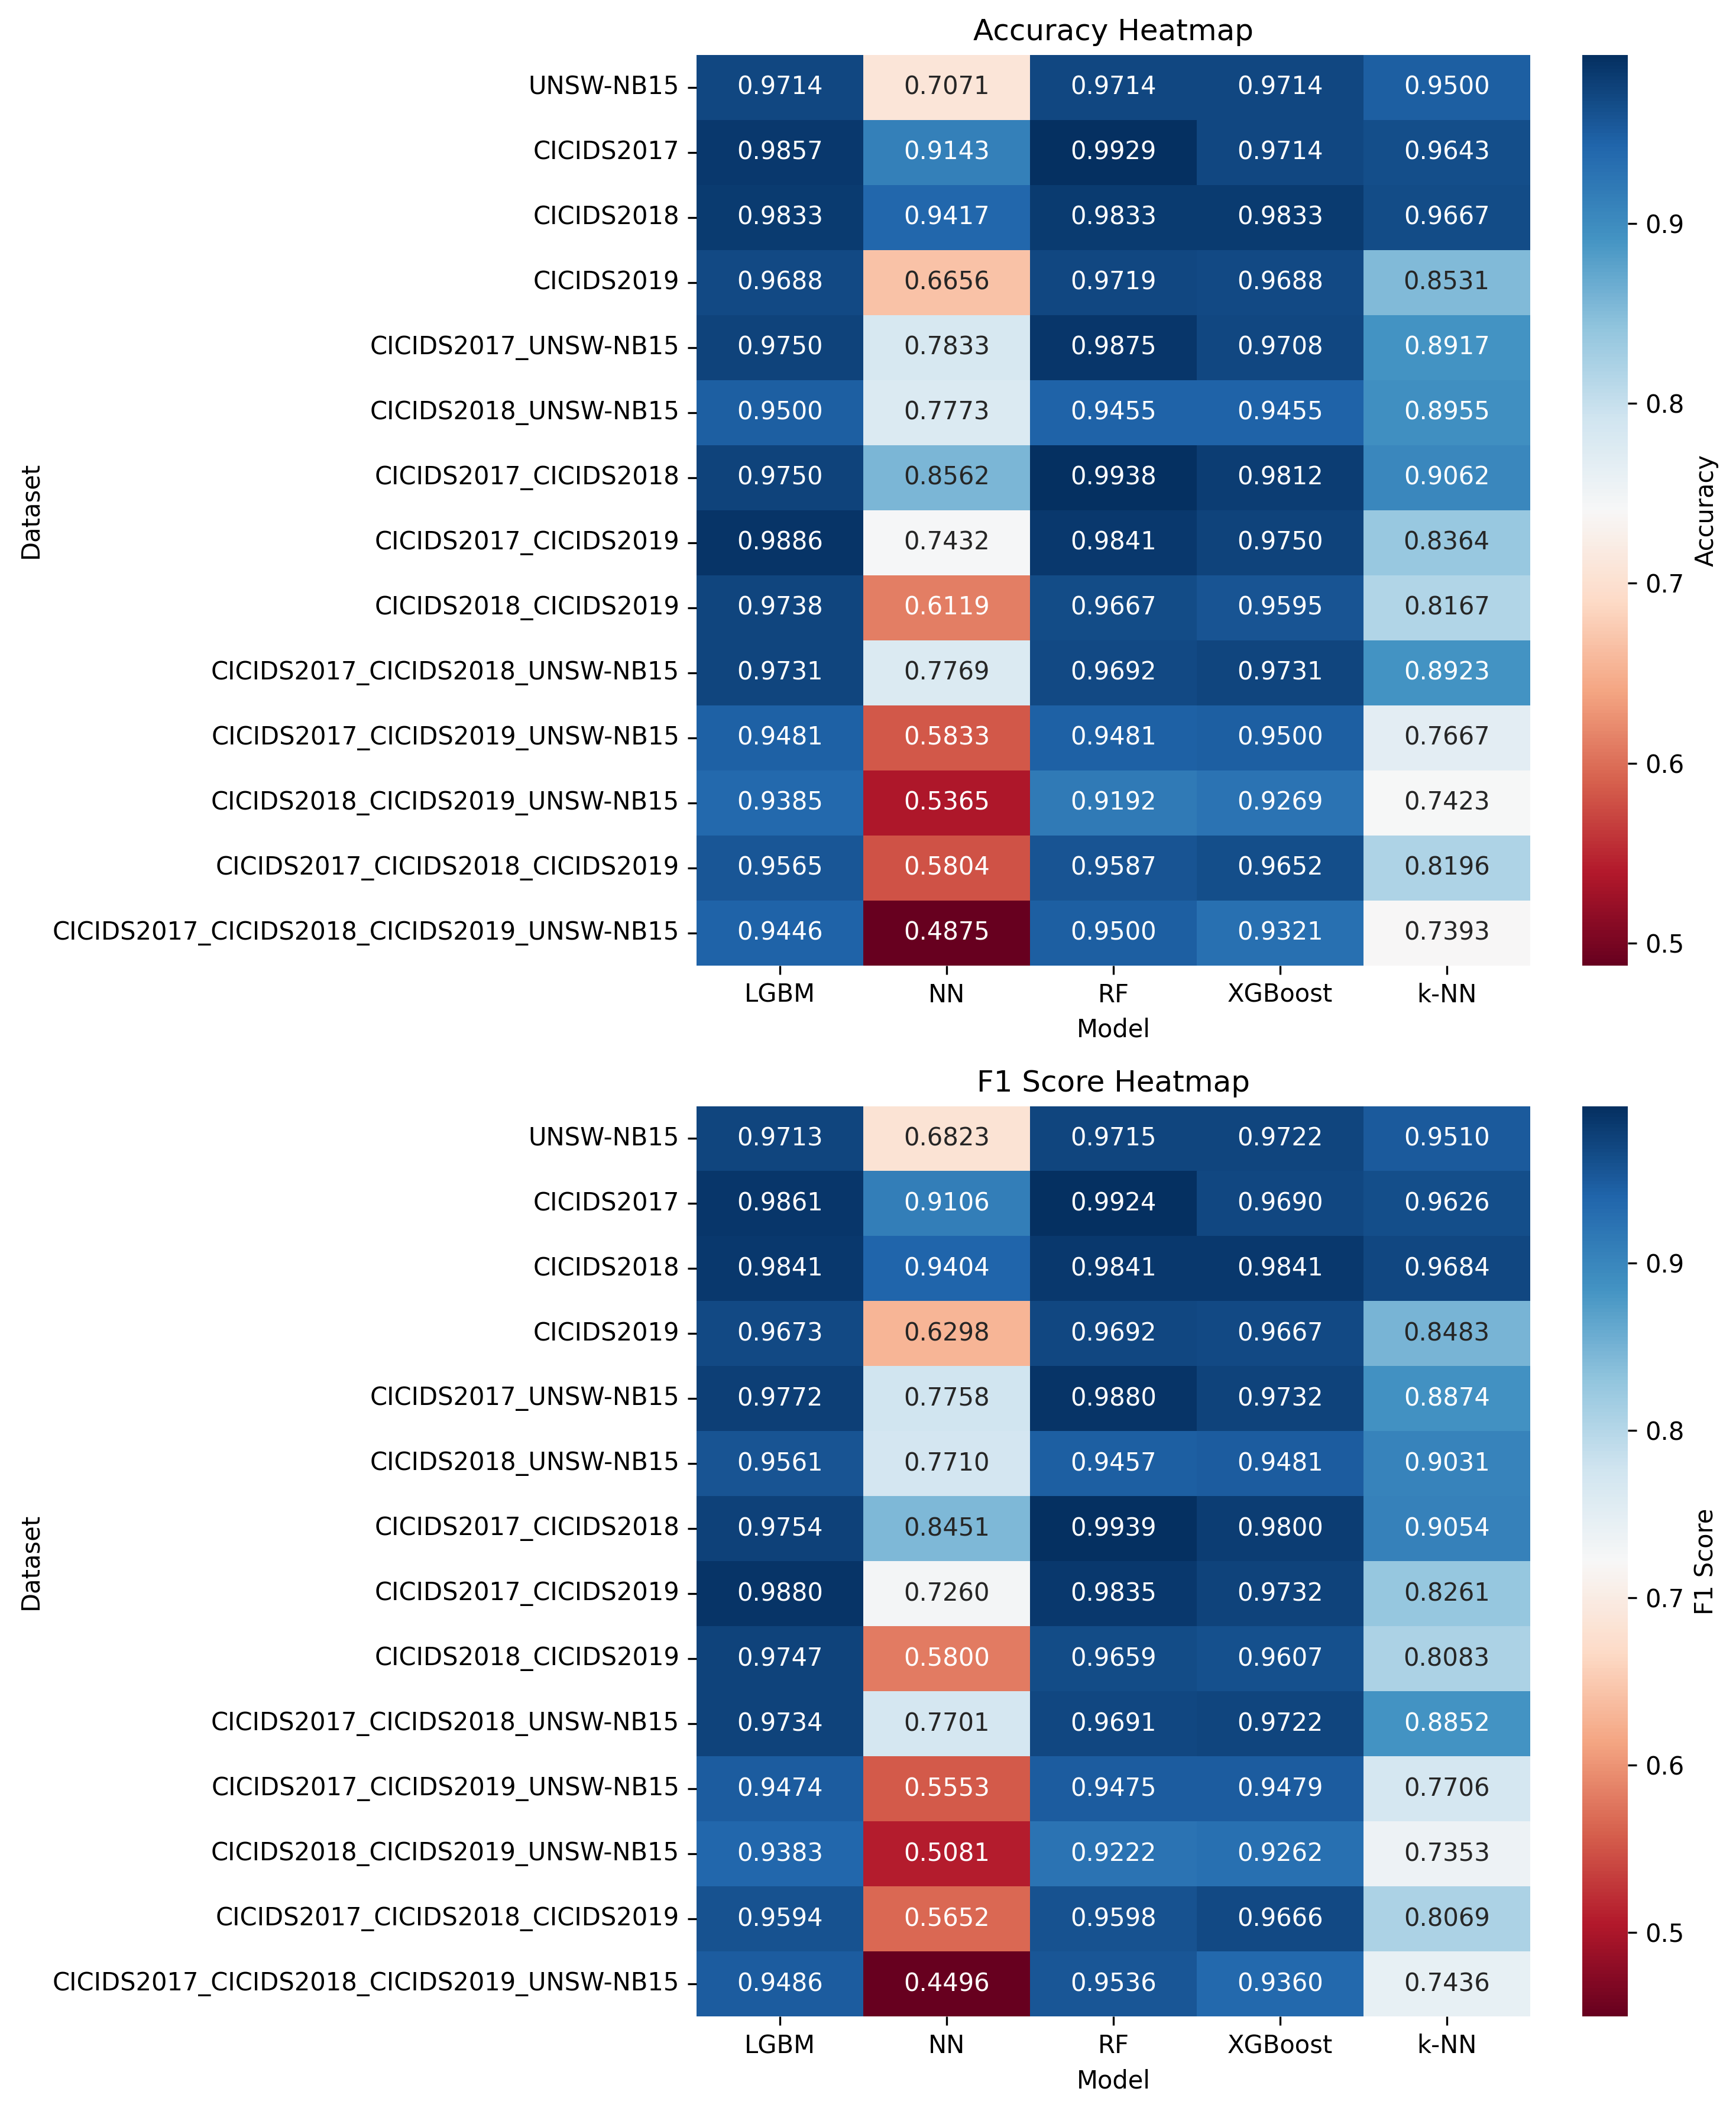

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare data
results_df = pd.read_csv('/home/alara/CiberIA_O1/results/combined_results.csv')
results_df.reset_index(inplace=True)
results_df['Method'] = results_df['Model'].apply(lambda x: x.split('_')[0])
results_df['Dataset'] = results_df['Model'].apply(lambda x: '_'.join(x.split('_')[1:]))

# Pivot tables
accuracy_df = results_df.pivot(index='Dataset', columns='Method', values='Accuracy')
f1_score_df = results_df.pivot(index='Dataset', columns='Method', values='F1 Score')
execution_time_df = results_df.pivot(index='Dataset', columns='Method', values='Execution Time')

# Sort datasets by name length
dataset_order = sorted(accuracy_df.index, key=len)
accuracy_df = accuracy_df.loc[dataset_order]
f1_score_df = f1_score_df.loc[dataset_order]
execution_time_df = execution_time_df.loc[dataset_order]

# Create 2x1 subplot grid for Accuracy and F1 Score
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), dpi=300)

# Accuracy Heatmap
sns.heatmap(accuracy_df, annot=True, fmt=".4f", cmap="RdBu", ax=axes[0], cbar_kws={'label': 'Accuracy'})
axes[0].set_title("Accuracy Heatmap")
axes[0].set_ylabel("Dataset")
axes[0].set_xlabel("Model")

# F1 Score Heatmap
sns.heatmap(f1_score_df, annot=True, fmt=".4f", cmap="RdBu", ax=axes[1], cbar_kws={'label': 'F1 Score'})
axes[1].set_title("F1 Score Heatmap")
axes[1].set_ylabel("Dataset")
axes[1].set_xlabel("Model")

# Ajustar espacio horizontal entre gráficos
plt.subplots_adjust(wspace=1)  # Puedes probar con 0.4 o 0.5 si quieres más separación

plt.tight_layout()
plt.savefig("accuracy_f1_heatmaps.png")
plt.show()



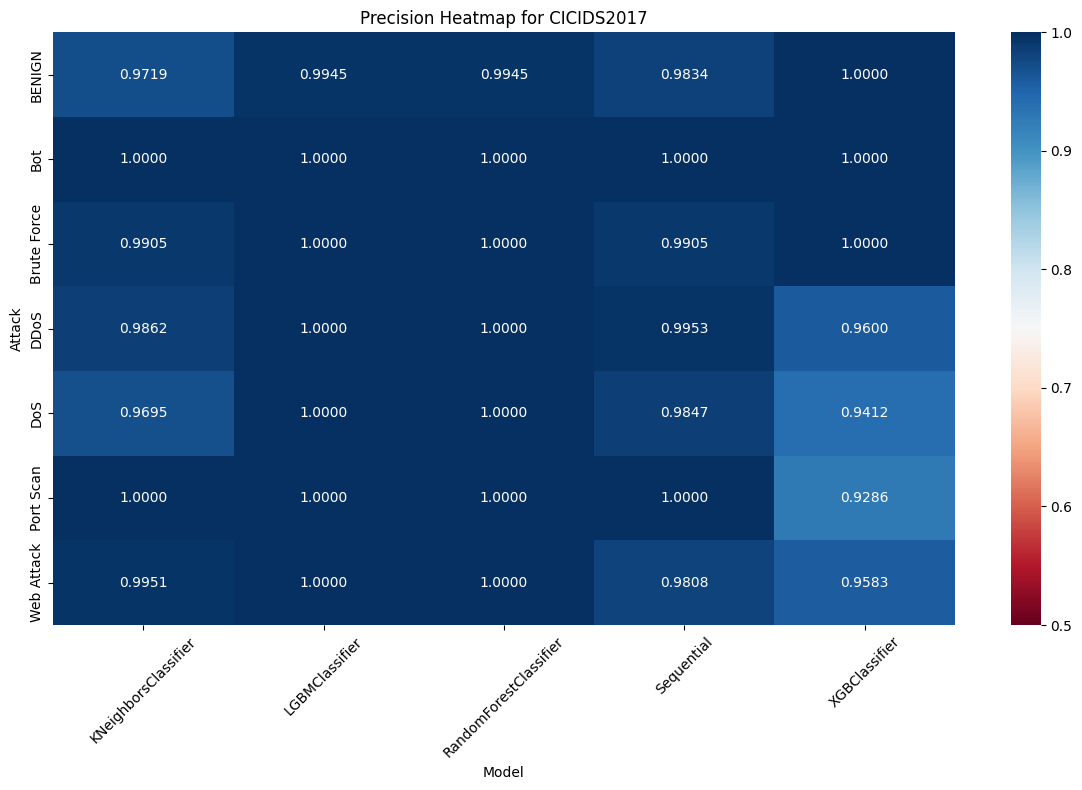

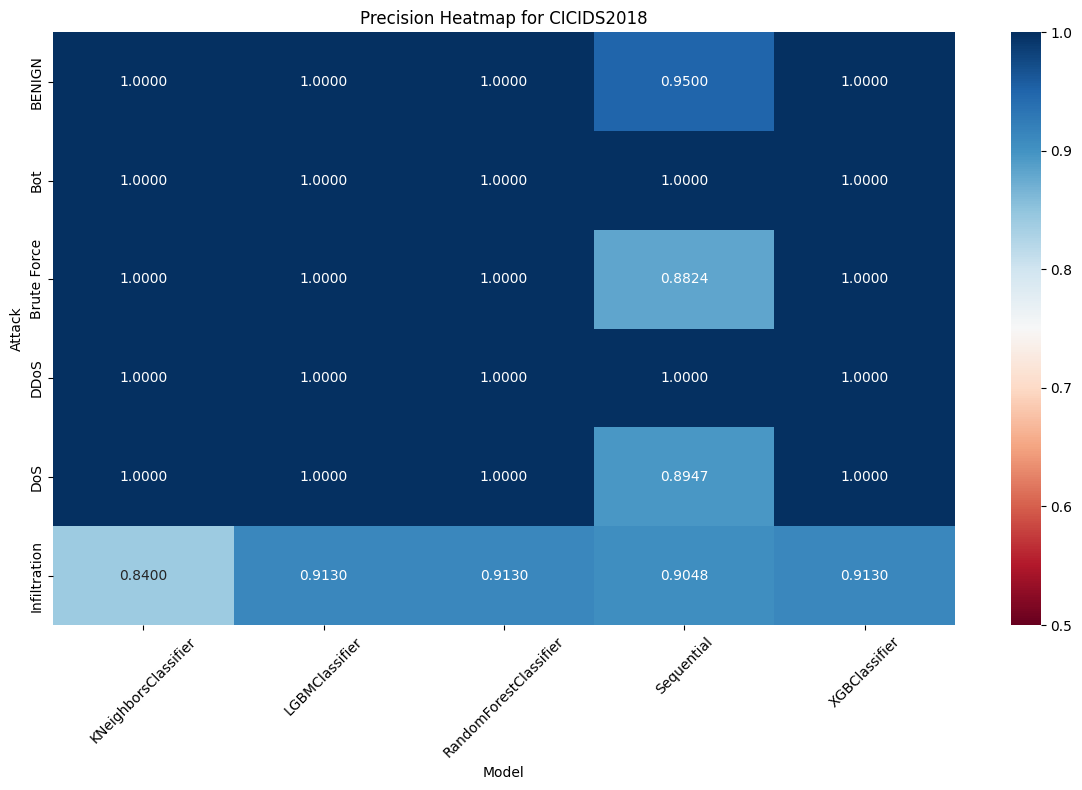

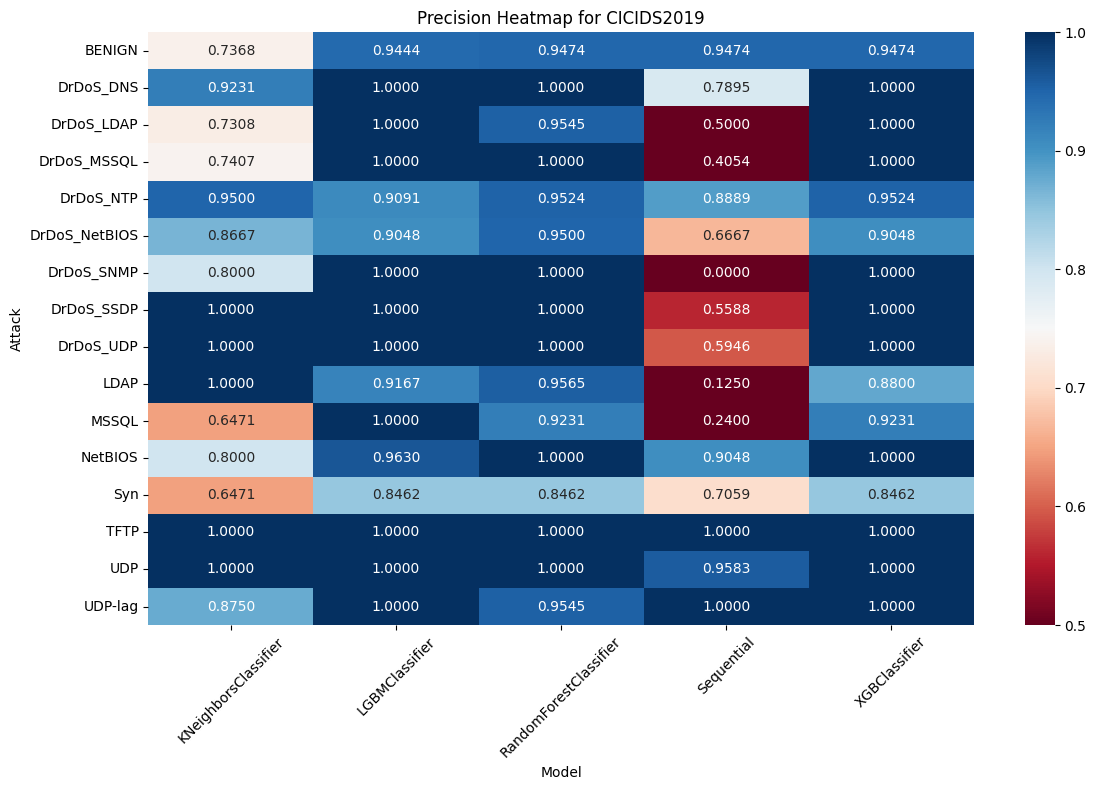

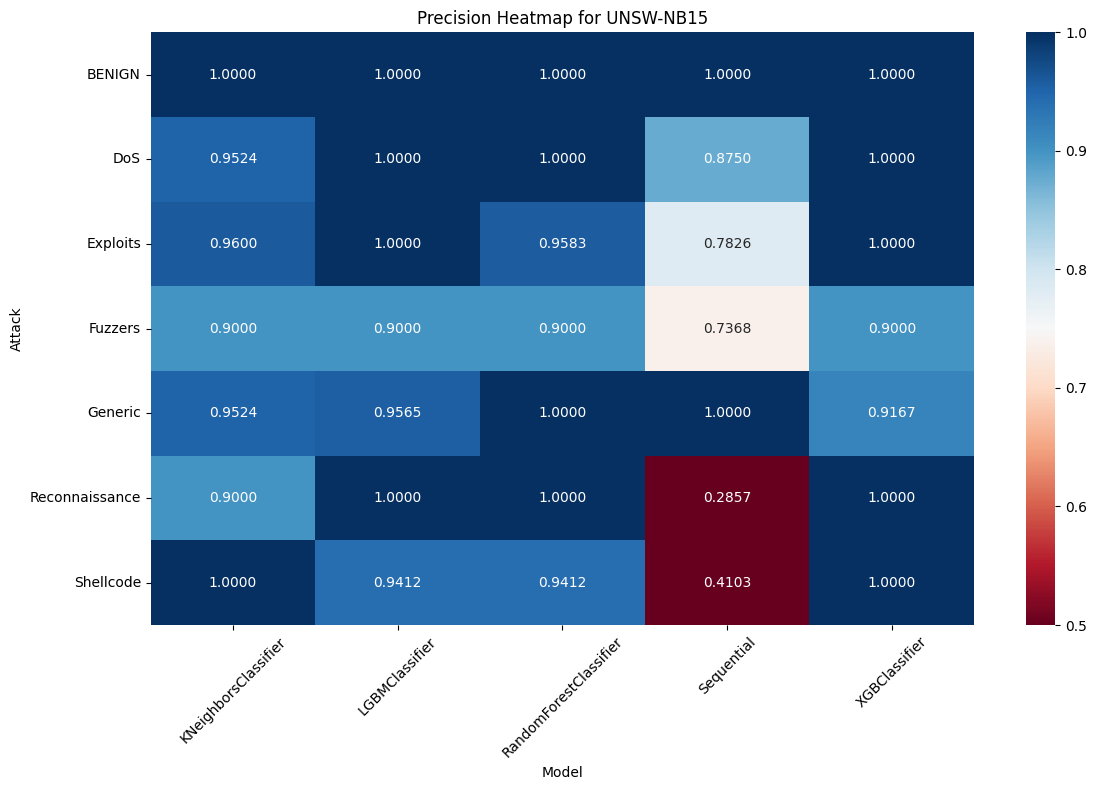

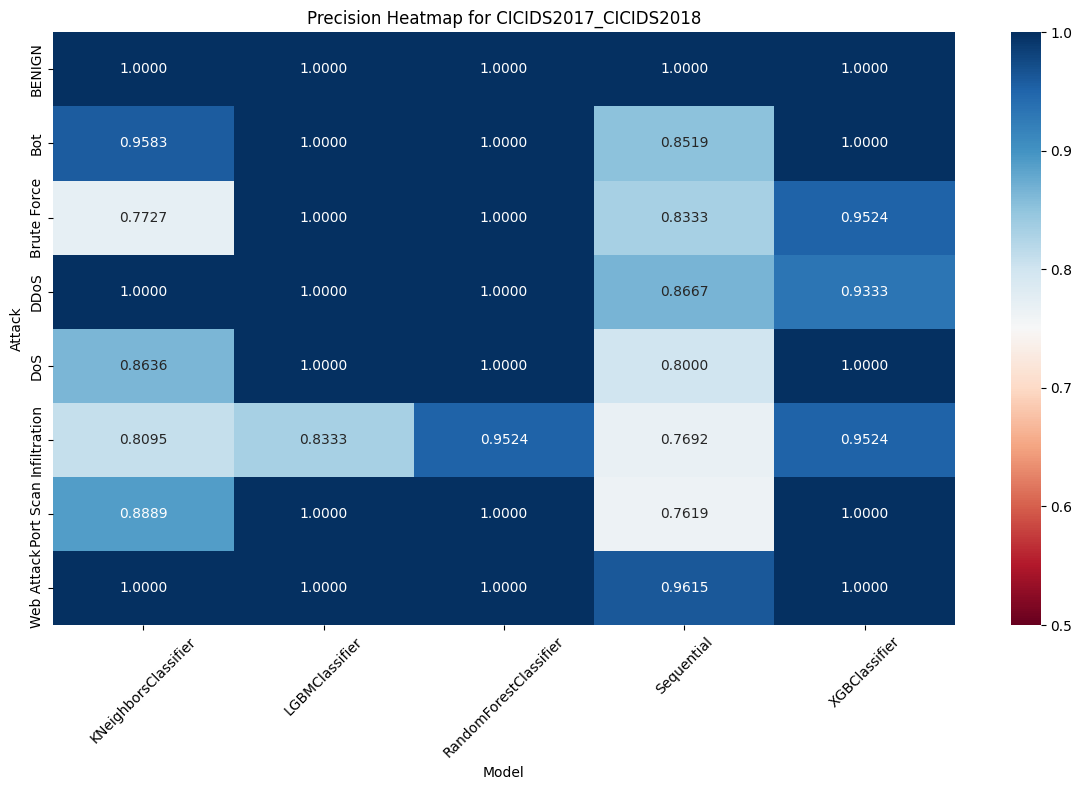

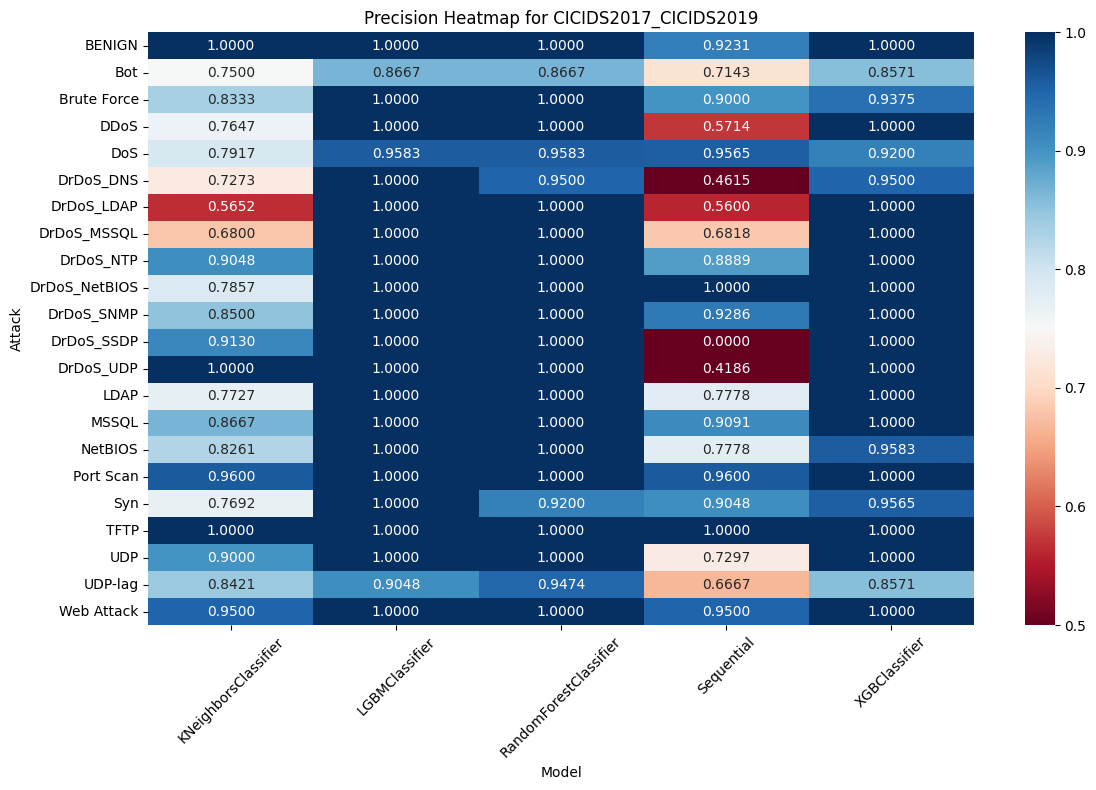

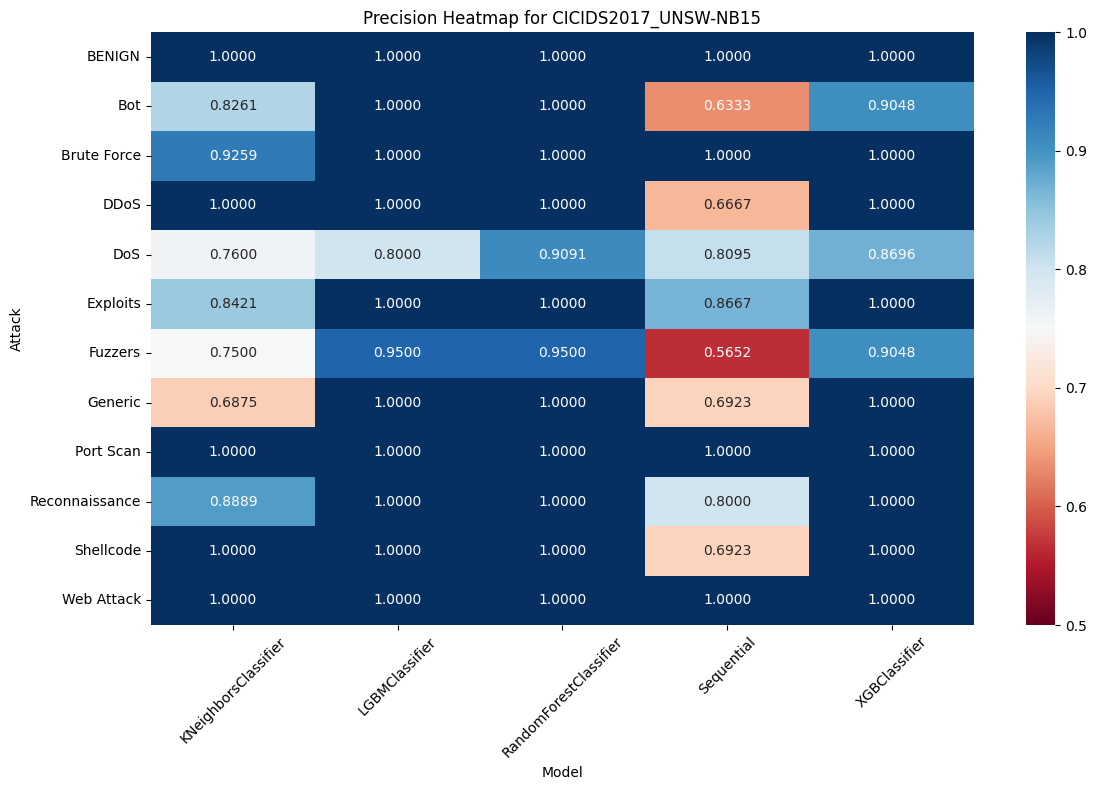

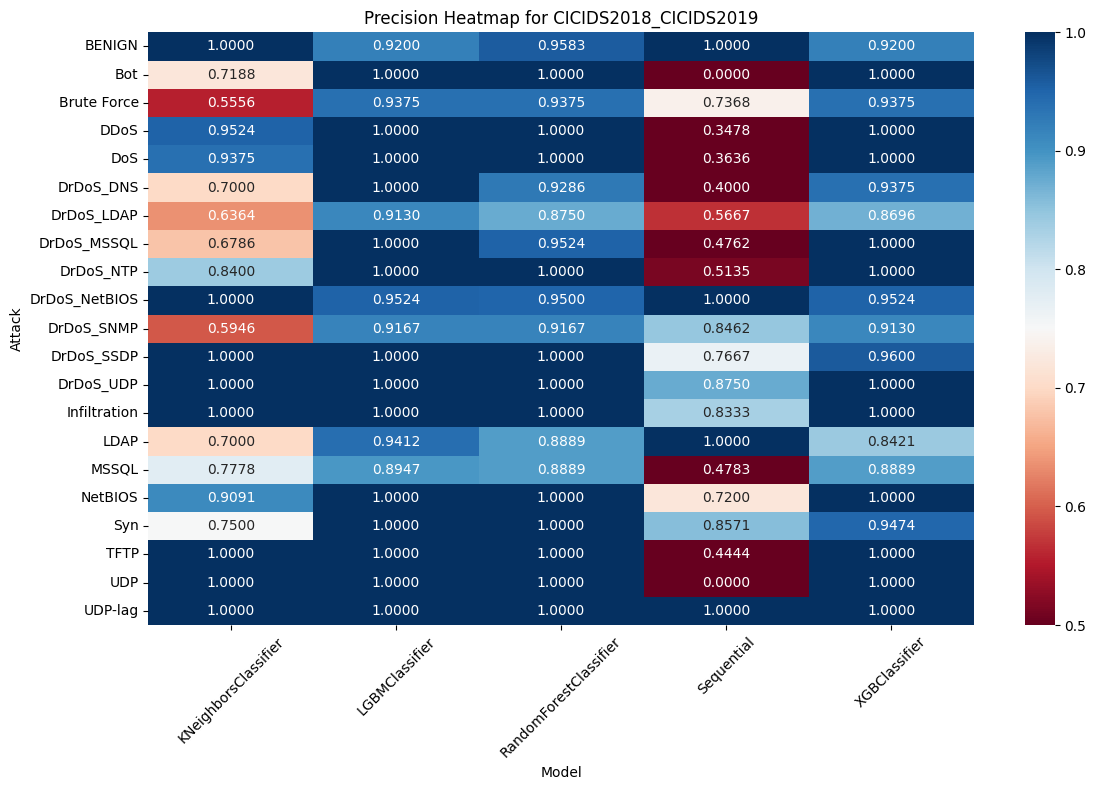

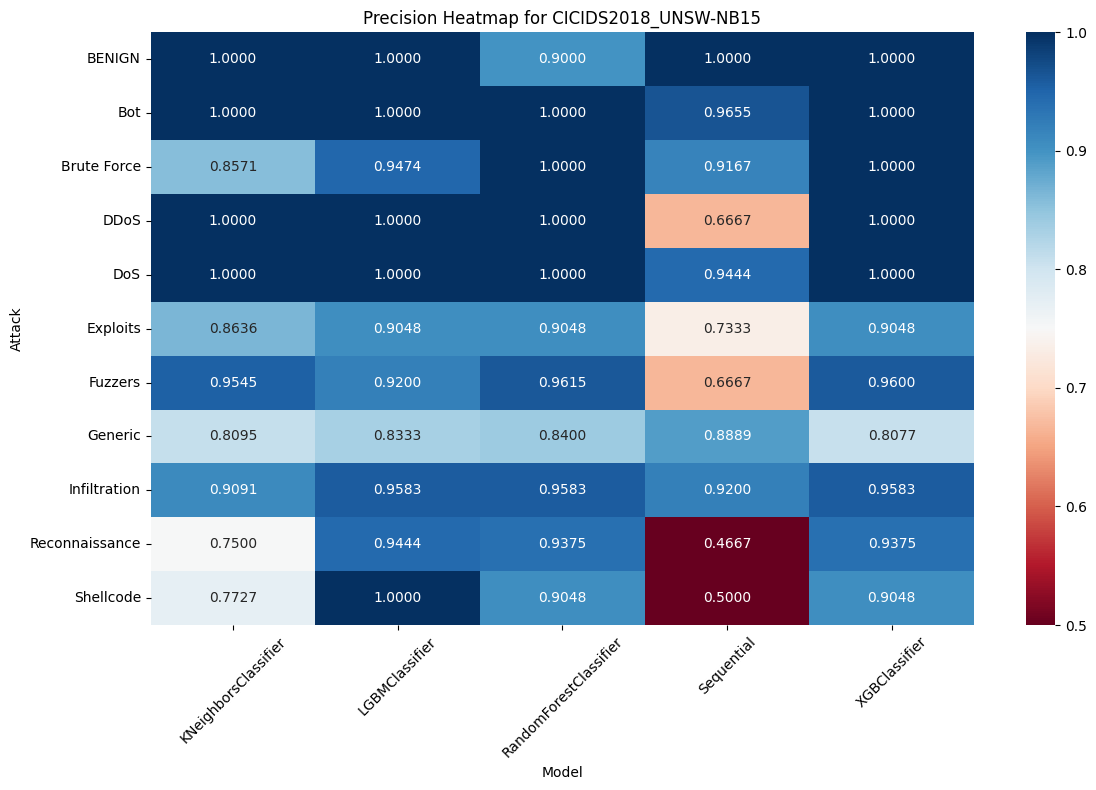

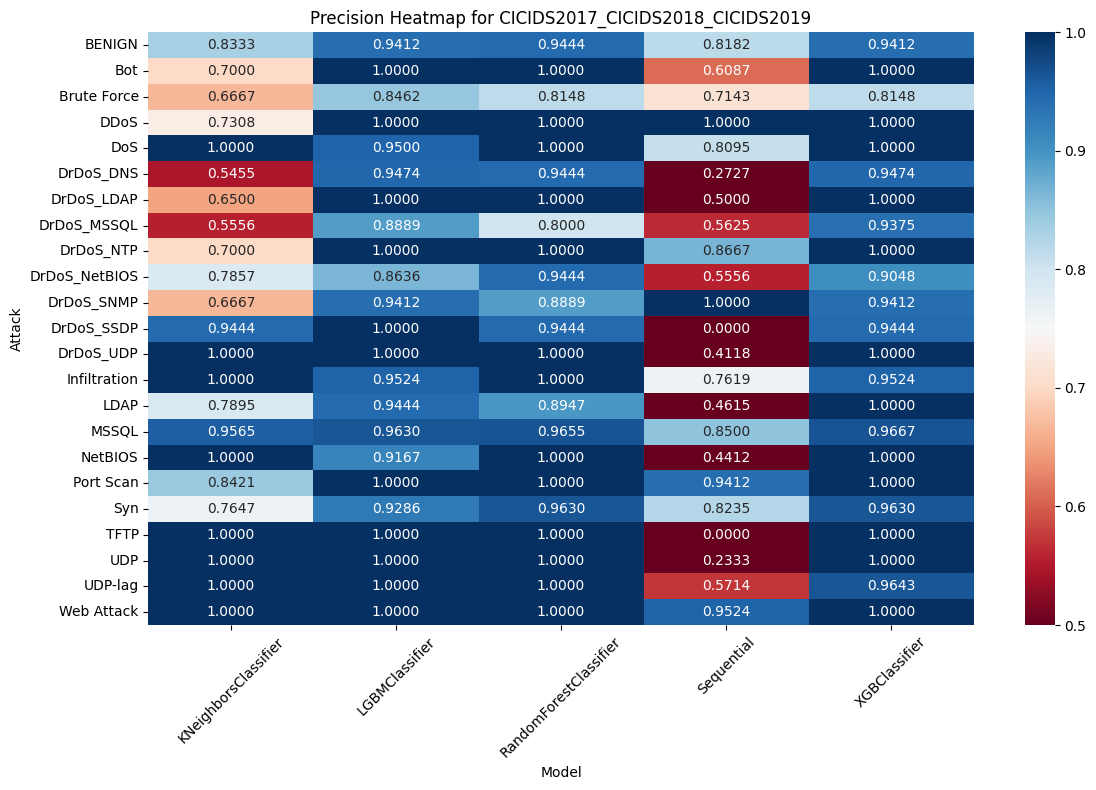

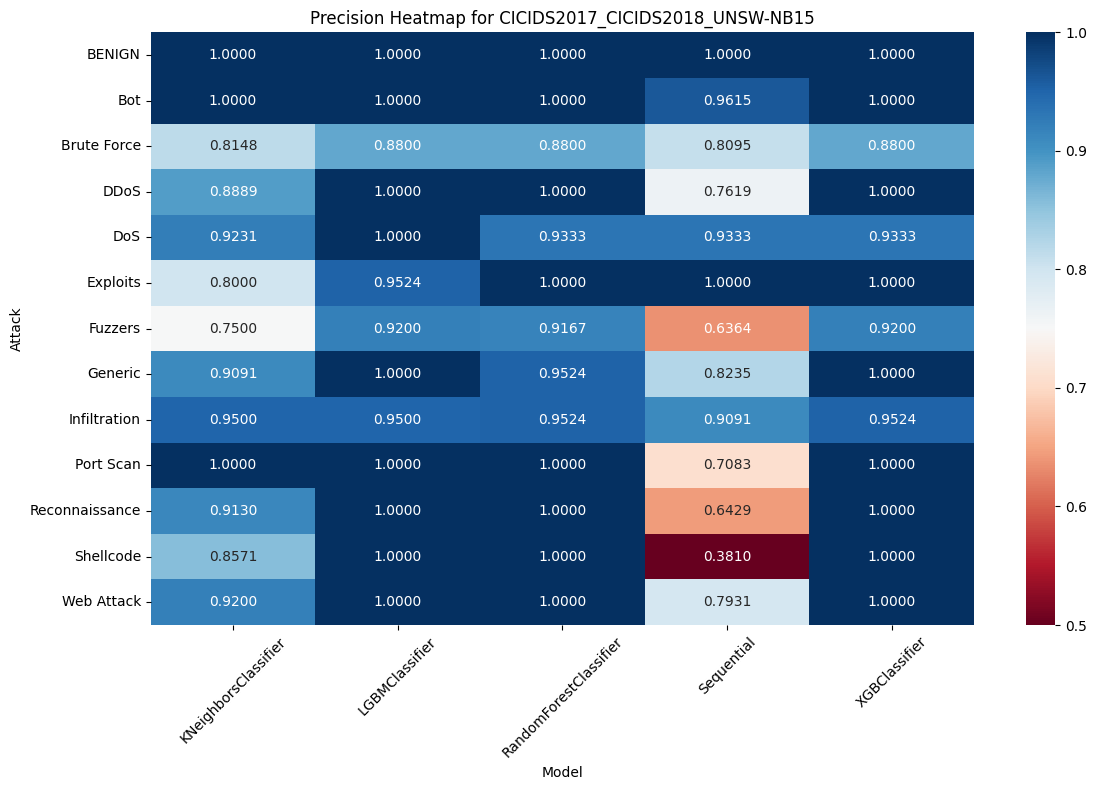

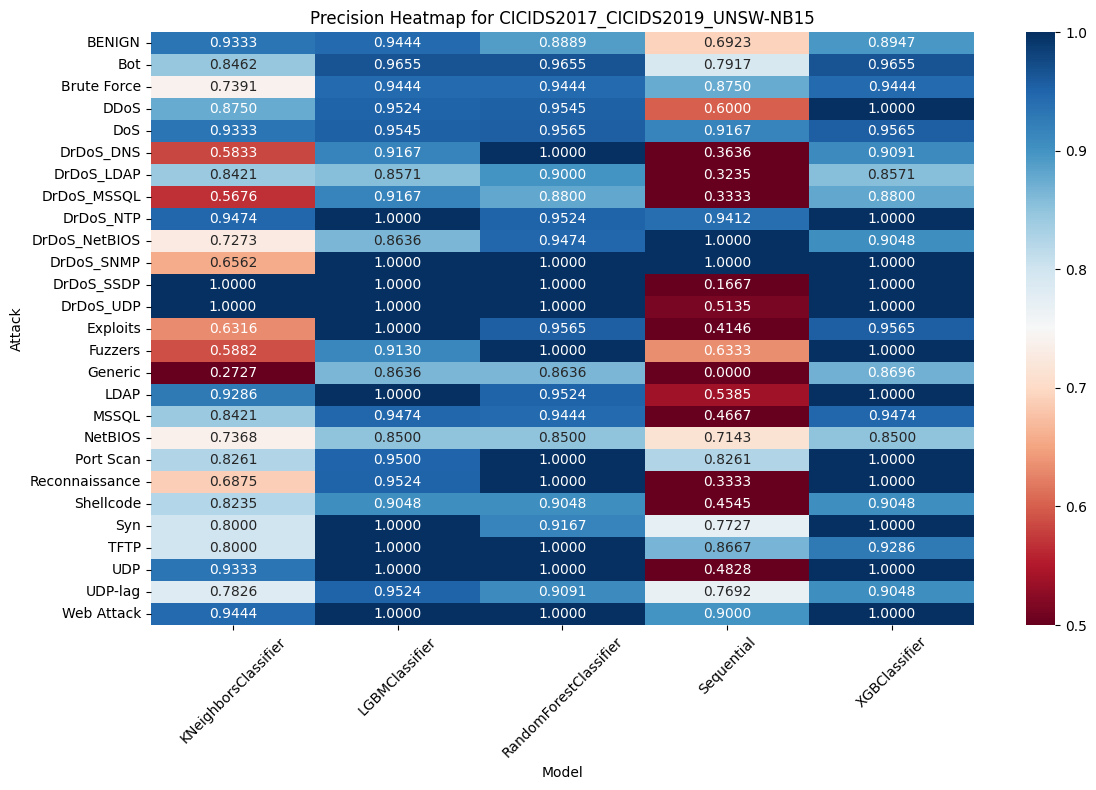

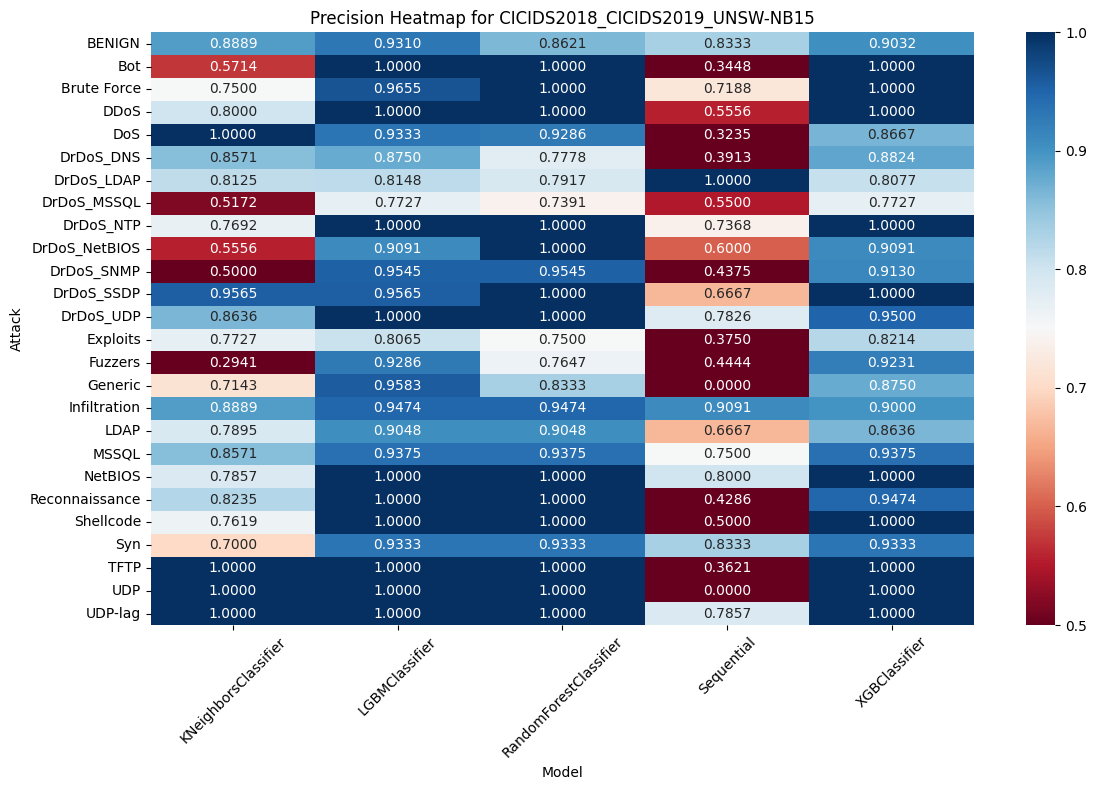

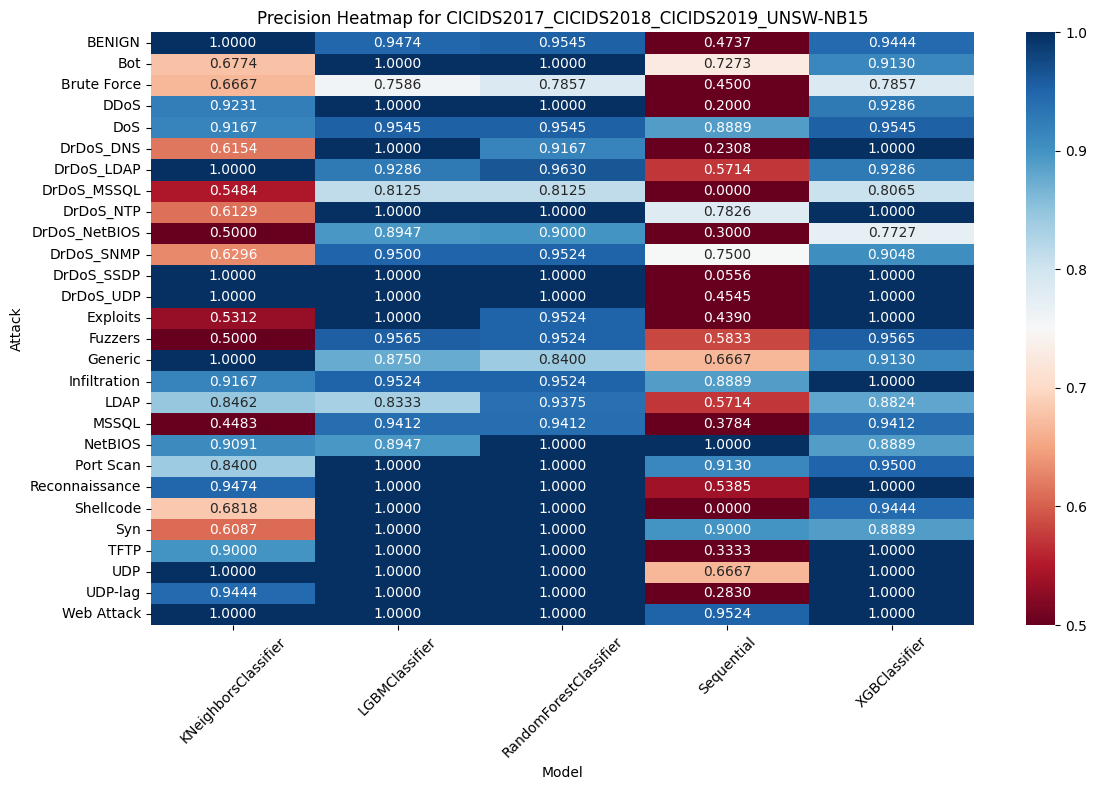

In [24]:
#get classification reports files per each dataset

report_dict = {}

for dataset in dataframes.keys():
    report_dict[dataset] = {}
    for file in os.listdir('/home/alara/CiberIA_O1/results/'):
        string_search = '_'.join(file.split('_')[:-3])
        if file.endswith('.csv') and string_search == dataset and 'classification_report' in file:
            model_name = file.split('_')[-3]
            if model_name not in report_dict[dataset]:
                report_dict[dataset][model_name] = []
            # Load the classification report CSV file
            report_file = f'/home/alara/CiberIA_O1/results/{dataset}_{model_name}_classification_report.csv'
            if os.path.exists(report_file):
                report_df = pd.read_csv(report_file)
                report_dict[dataset][model_name] = report_df


# Loop over each dataset in report_dict
for dataset, model_reports in report_dict.items():
    # Dictionary to hold a Series of precisions keyed by model
    heatmap_data = {}
    for model, df in model_reports.items():
        # If the CSV contains an index column saved as "Unnamed: 0" or "class", set that as index.
        if df.columns[0] in ['Unnamed: 0', 'class']:
            df.set_index(df.columns[0], inplace=True)
        # Drop summary rows if present (for example: 'accuracy', 'macro avg', 'weighted avg')
        df_filtered = df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
        # Use the 'precision' column as the values. The index of df_filtered should now be the attack labels.
        heatmap_data[model] = df_filtered['precision']
    
    # Build a DataFrame where columns are models and rows are attack classes.
    df_heatmap = pd.DataFrame(heatmap_data)

    # Sort the columns alphabetically
    df_heatmap = df_heatmap[sorted(df_heatmap.columns)]

    plt.figure(figsize=(12, 8))
    ax = sns.heatmap(df_heatmap, annot=True, fmt=".4f", cmap="RdBu", vmin=0.5, vmax=1)
    plt.title(f"Precision Heatmap for {dataset}")
    plt.xlabel("Model")
    plt.xticks(rotation=45)
    plt.ylabel("Attack")
    plt.tight_layout()
    plt.show()

In [60]:
import pickle
# load model dictionary from file
with open('/home/alara/CiberIA_O1/results/model_dict.pkl', 'rb') as f:
    model_dict = pickle.load(f)

model_dict = {k: v for k, v in model_dict.items() if not k.startswith('NN_')}
model_dict = {k: v for k, v in model_dict.items() if not k.startswith('XGBoost')}

# coge los primeros 20 modelos solo
model_dict_single = {k: model_dict[k] for k in list(model_dict.keys())[:20]}

# eilimna los que empicen por NN

print(model_dict_single.keys())
print(model_dict.keys())


dict_keys(['RF_CICIDS2017', 'k-NN_CICIDS2017', 'LGBM_CICIDS2017', 'RF_CICIDS2018', 'k-NN_CICIDS2018', 'LGBM_CICIDS2018', 'RF_CICIDS2019', 'k-NN_CICIDS2019', 'LGBM_CICIDS2019', 'RF_UNSW-NB15', 'k-NN_UNSW-NB15', 'LGBM_UNSW-NB15', 'RF_CICIDS2017_CICIDS2018', 'k-NN_CICIDS2017_CICIDS2018', 'LGBM_CICIDS2017_CICIDS2018', 'RF_CICIDS2017_CICIDS2019', 'k-NN_CICIDS2017_CICIDS2019', 'LGBM_CICIDS2017_CICIDS2019', 'RF_CICIDS2017_UNSW-NB15', 'k-NN_CICIDS2017_UNSW-NB15'])
dict_keys(['RF_CICIDS2017', 'k-NN_CICIDS2017', 'LGBM_CICIDS2017', 'RF_CICIDS2018', 'k-NN_CICIDS2018', 'LGBM_CICIDS2018', 'RF_CICIDS2019', 'k-NN_CICIDS2019', 'LGBM_CICIDS2019', 'RF_UNSW-NB15', 'k-NN_UNSW-NB15', 'LGBM_UNSW-NB15', 'RF_CICIDS2017_CICIDS2018', 'k-NN_CICIDS2017_CICIDS2018', 'LGBM_CICIDS2017_CICIDS2018', 'RF_CICIDS2017_CICIDS2019', 'k-NN_CICIDS2017_CICIDS2019', 'LGBM_CICIDS2017_CICIDS2019', 'RF_CICIDS2017_UNSW-NB15', 'k-NN_CICIDS2017_UNSW-NB15', 'LGBM_CICIDS2017_UNSW-NB15', 'RF_CICIDS2018_CICIDS2019', 'k-NN_CICIDS2018_CICID

In [61]:
from time import time
def evaluate_model_no_training(model, X_test, y_test, key, model_name, is_neural=False):
    
    start_time = time()

    le = LabelEncoder()
    if is_neural:
        # For neural models, assume predictions output probabilities
        y_pred_prob = model.predict(X_test)
        y_pred = np.unique(y_test)[np.argmax(y_pred_prob, axis=1)]
    else:
        # For models that require label encoding
        if isinstance(model, (xgb.XGBClassifier, SVC)):
            le.fit(y_test)
            y_pred_encoded = model.predict(X_test)
            y_pred = le.inverse_transform(y_pred_encoded)
        else:
            y_pred = model.predict(X_test)
    
    exec_time = time() - start_time
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    # Save classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(f'/home/alara/CiberIA_O1/results/CROSS/CROSS_{key}_w_{model_name}_classification_report.csv')
    
    return accuracy, f1, exec_time

In [62]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import tqdm
from imblearn.over_sampling import SMOTE

results = {}
samples_per_class = 1000

for key, df in tqdm.tqdm(dataframes.items(), desc="Datasets"):
    for model in tqdm.tqdm(model_dict.keys(), desc="Pretrained models"):
        print(f"Processing {key} with model {model}...")

        le = LabelEncoder()
        df['Attack Number'] = le.fit_transform(df['Attack Type'])

        for col in df.columns:
            col_type = df[col].dtype
            if col_type != object:
                c_min = df[col].min()
                c_max = df[col].max()
                if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
        new_memory_usage = df.memory_usage().sum() / 1024 ** 2

        data = df.copy()

        attacks = data['Attack Type']
        data = data.select_dtypes(include=['float32', 'int32'])

        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(data)

        size = len(data.columns) // 2
        pca = PCA(n_components=size)
        transformed_features = pca.fit_transform(scaled_features)
        print(f'Information retained: {sum(pca.explained_variance_ratio_):.2%}')
        new_data_pca = pd.DataFrame(transformed_features, columns=[f'PC{i+1}' for i in range(size)])
        new_data_pca['Attack Type'] = attacks.values

        class_counts = new_data_pca['Attack Type'].value_counts()
        selected_classes = class_counts[class_counts > 1950]
        class_names = selected_classes.index
        selected = new_data_pca[new_data_pca['Attack Type'].isin(class_names)]
        
        dfs = []
        for name in class_names:
            df_class = selected[selected['Attack Type'] == name]
            if len(df_class) > 1950:
                df_class = df_class.sample(n=samples_per_class, replace=True, random_state=0)
            dfs.append(df_class)
        
        balanced_df = pd.concat(dfs, ignore_index=True)
        X = balanced_df.drop('Attack Type', axis=1)
        y = balanced_df['Attack Type']
        smote = SMOTE(sampling_strategy='auto', random_state=0)
        X_upsampled, y_upsampled = smote.fit_resample(X, y)
        balanced_data = pd.DataFrame(X_upsampled)
        balanced_data['Attack Type'] = y_upsampled
        balanced_data = balanced_data.sample(frac=1)
        X_train, X_test, y_train, y_test = train_test_split(balanced_data.drop('Attack Type', axis=1), balanced_data['Attack Type'], test_size=0.2, random_state=42)

        print(f"Training {key} with {model}...")
        model_pre = model_dict[model]
        from time import time
        acc, f1, time = evaluate_model_no_training(model_pre, X_test, y_test, key, model, is_neural=isinstance(model_pre, Sequential))
        results[f'{model}_w_{key}'] = (acc, f1, time)

        print(f"Finished processing {key} with model {model}")
        print(f"Accuracy: {acc}, F1 Score: {f1}, Execution Time: {time:.2f} seconds")

#save results to csv
results_df = pd.DataFrame(results, index=['Accuracy', 'F1 Score', 'Execution Time']).T
results_df.columns = ['Accuracy', 'F1 Score', 'Execution Time']
results_df.index.name = 'Model'
results_df.to_csv('/home/alara/CiberIA_O1/results/cross_single_combined_results.csv', index=True)

            

Pretrained models:   0%|                                                     | 0/42 [00:00<?, ?it/s]

Processing CICIDS2017 with model RF_CICIDS2017...
Information retained: 98.78%



Pretrained models:   2%|█                                            | 1/42 [00:04<02:57,  4.33s/it]

Training CICIDS2017 with RF_CICIDS2017...
Finished processing CICIDS2017 with model RF_CICIDS2017
Accuracy: 0.9814285714285714, F1 Score: 0.9809978261100059, Execution Time: 0.04 seconds
Processing CICIDS2017 with model k-NN_CICIDS2017...
Information retained: 98.78%



Pretrained models:   5%|██▏                                          | 2/42 [00:08<02:49,  4.24s/it]

...

Training CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15 with RF_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15...
Finished processing CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15 with model RF_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15
Accuracy: 0.9483928571428571, F1 Score: 0.9490269915513238, Execution Time: 0.06 seconds
Processing CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15 with model k-NN_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15...
Information retained: 98.24%



Pretrained models:  98%|██████████████████████████████████████████▉ | 41/42 [56:11<01:22, 82.46s/it]

Training CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15 with k-NN_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15...
Finished processing CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15 with model k-NN_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15
Accuracy: 0.7539285714285714, F1 Score: 0.7371079828474701, Execution Time: 0.12 seconds
Processing CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15 with model LGBM_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15...
Information retained: 98.24%



Datasets: 100%|█████████████████████████████████████████████████| 14/14 [6:09:47<00:00, 1584.83s/it]

Training CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15 with LGBM_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15...
Finished processing CICIDS2017_CICIDS2018_CICDDoS2019_UNSW-NB15 with model LGBM_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15
Accuracy: 0.9525, F1 Score: 0.9520151453589293, Execution Time: 0.08 seconds


In [63]:
# Load the CSV
results = pd.read_csv('/home/alara/CiberIA_O1/results/cross_single_combined_results.csv')

# Print the DataFrame (optional for inspection)
print(results)

# Transform each row into a dictionary entry
results_dict = {}

for _, row in results.iterrows():
    key = row['Model']  # or use 'Model_Name' depending on your column
    results_dict[key] = {
        'Accuracy': row['Accuracy'],
        'F1 Score': row['F1 Score'],
        'Execution Time': row['Execution Time']
    }

# Print formatted output
for key, value in results_dict.items():
    print(f"{key}: Accuracy: {value['Accuracy']:.4f}, F1 Score: {value['F1 Score']:.4f}, Execution Time: {value['Execution Time']:.2f} seconds")

                                                 Model  Accuracy  F1 Score  \
0                           RF_CICIDS2017_w_CICIDS2017  0.981429  0.980998   
1                         k-NN_CICIDS2017_w_CICIDS2017  0.949286  0.947791   
2                         LGBM_CICIDS2017_w_CICIDS2017  0.981429  0.980625   
3                           RF_CICIDS2018_w_CICIDS2017  0.141429  0.032205   
4                         k-NN_CICIDS2018_w_CICIDS2017  0.125714  0.035256   
..                                                 ...       ...       ...   
583  k-NN_CICIDS2018_CICIDS2019_UNSW-NB15_w_CICIDS2...  0.289821  0.254233   
584  LGBM_CICIDS2018_CICIDS2019_UNSW-NB15_w_CICIDS2...  0.374464  0.314646   
585  RF_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB15_...  0.948393  0.949027   
586  k-NN_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB1...  0.753929  0.737108   
587  LGBM_CICIDS2017_CICIDS2018_CICIDS2019_UNSW-NB1...  0.952500  0.952015   

     Execution Time  
0          0.039451  
1          0.066752

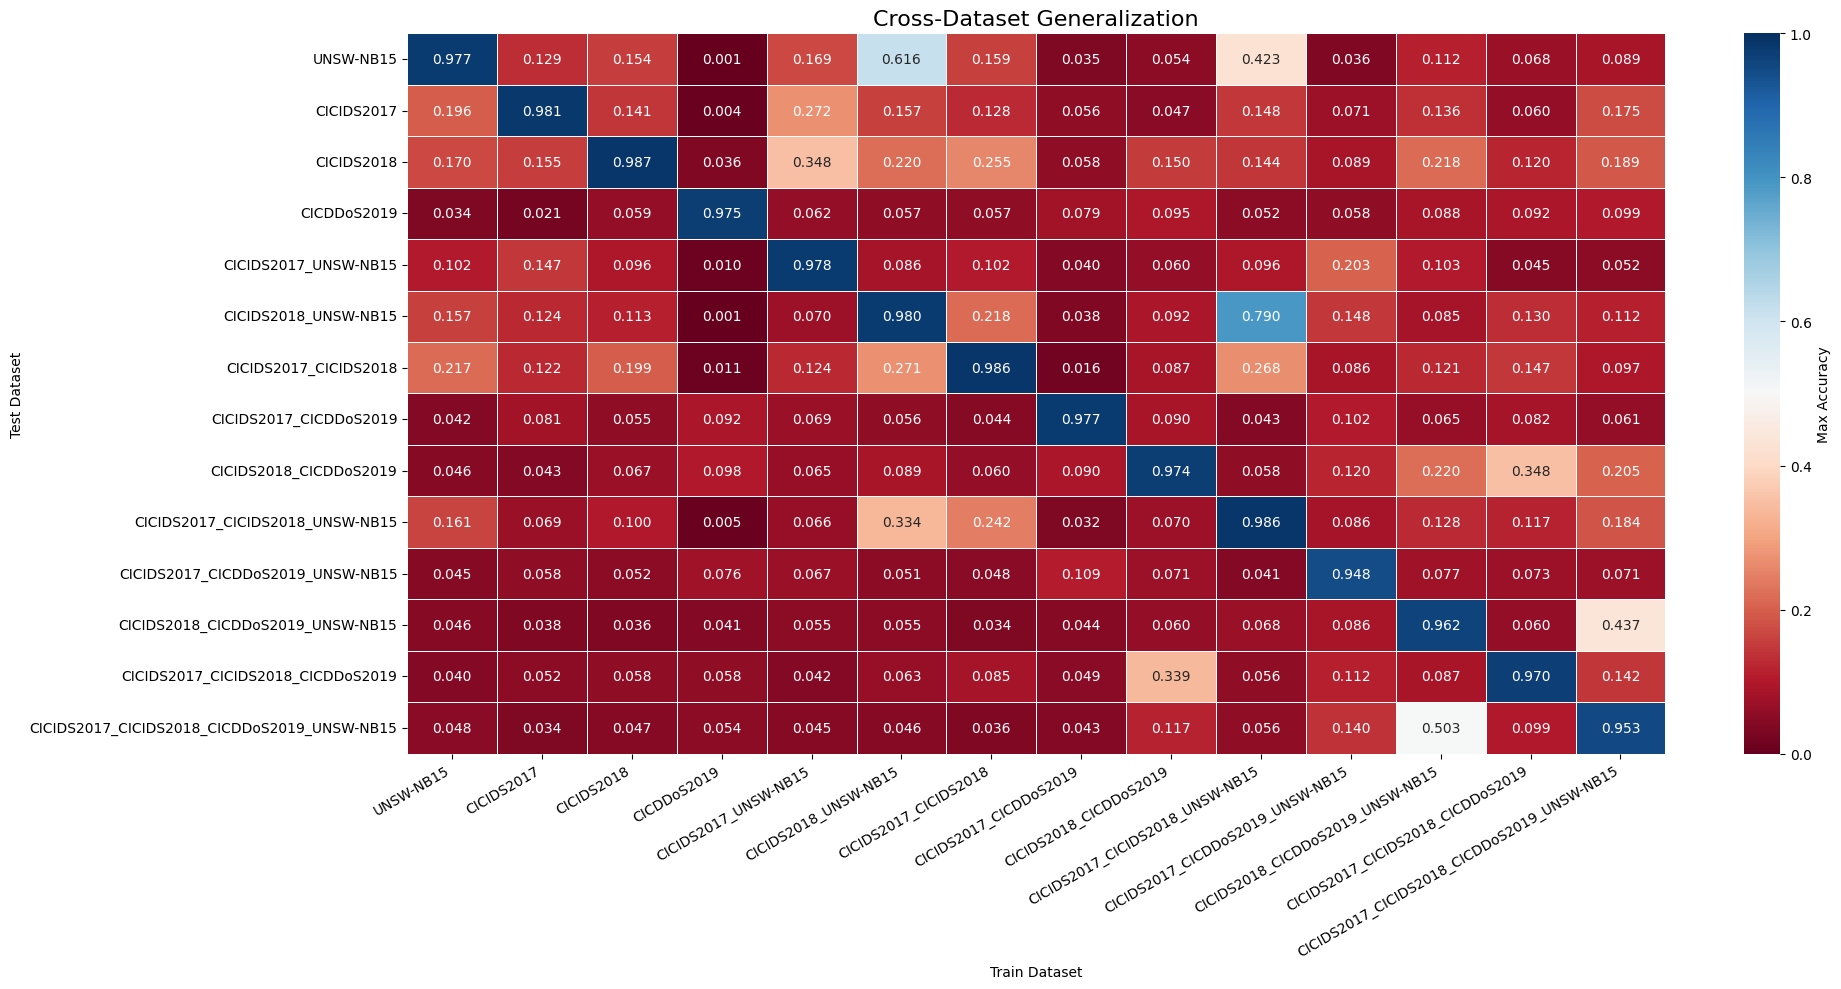

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

available_models = ['RF', 'LGBM', 'k-NN']
all_entries = []

# Recolectar datos de todos los modelos
for model in available_models:
    filtered_results = {k: v for k, v in results_dict.items() if k.startswith(model)}
    df = pd.DataFrame(filtered_results, index=['Accuracy', 'F1 Score', 'Execution Time']).T
    df.columns = ['Accuracy', 'F1 Score', 'Execution Time']
    df['Model'] = model
    df['Dataset_1'] = df.index.astype(str).str.split('_w_').str[0].str.replace(f'{model}_', '', regex=False)
    df['Dataset_2'] = df.index.astype(str).str.split('_w_').str[1]
    all_entries.append(df)

# Combinar los datos
combined_df = pd.concat(all_entries)

# Renombrar antes del agrupamiento
combined_df['Dataset_1'] = combined_df['Dataset_1'].replace('CICIDS2019', 'CICDDoS2019')
combined_df['Dataset_2'] = combined_df['Dataset_2'].replace('CICIDS2019', 'CICDDoS2019')

# Calcular el máximo Accuracy por combinación
max_accuracy_df = (
    combined_df
    .groupby(['Dataset_2', 'Dataset_1'])['Accuracy']
    .max()
    .unstack()
)

# Renombrar también en el index y columnas (por si el reemplazo anterior no cubre todos)
max_accuracy_df.index = max_accuracy_df.index.str.replace('CICIDS2019', 'CICDDoS2019')
max_accuracy_df.columns = max_accuracy_df.columns.str.replace('CICIDS2019', 'CICDDoS2019')

# Ordenar por longitud
sorted_columns = sorted(max_accuracy_df.columns, key=len)
sorted_index = sorted(max_accuracy_df.index, key=len)
max_accuracy_df = max_accuracy_df.loc[sorted_index, sorted_columns]

# Plot
plt.figure(figsize=(20, 10))
sns.heatmap(max_accuracy_df, annot=True, fmt=".3f", cmap="RdBu", vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Max Accuracy'})

plt.title('Cross-Dataset Generalization', fontsize=16)
plt.xlabel('Train Dataset')
plt.ylabel('Test Dataset')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("max_accuracy_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()




In [202]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import tqdm
from imblearn.over_sampling import SMOTE

results = {}
samples_per_class = 500

for key, df in tqdm.tqdm(base_dataframe.items(), desc="Datasets"):
    for model in tqdm.tqdm(model_dict.keys(), desc="Pretrained models"):
        print(f"Processing {key} with model {model}...")

        le = LabelEncoder()
        df['Attack Number'] = le.fit_transform(df['Attack Type'])

        for col in df.columns:
            col_type = df[col].dtype
            if col_type != object:
                c_min = df[col].min()
                c_max = df[col].max()
                if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
        new_memory_usage = df.memory_usage().sum() / 1024 ** 2

        data = df.copy()

        attacks = data['Attack Type']
        data = data.select_dtypes(include=['float32', 'int32'])

        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(data)

        size = len(data.columns) // 2
        pca = PCA(n_components=size)
        transformed_features = pca.fit_transform(scaled_features)
        print(f'Information retained: {sum(pca.explained_variance_ratio_):.2%}')
        new_data_pca = pd.DataFrame(transformed_features, columns=[f'PC{i+1}' for i in range(size)])
        new_data_pca['Attack Type'] = attacks.values

        class_counts = new_data_pca['Attack Type'].value_counts()
        selected_classes = class_counts[class_counts > 1950]
        class_names = selected_classes.index
        selected = new_data_pca[new_data_pca['Attack Type'].isin(class_names)]
        
        dfs = []
        for name in class_names:
            df_class = selected[selected['Attack Type'] == name]
            if len(df_class) > 1950:
                df_class = df_class.sample(n=samples_per_class, replace=True, random_state=0)
            dfs.append(df_class)
        
        balanced_df = pd.concat(dfs, ignore_index=True)
        X = balanced_df.drop('Attack Type', axis=1)
        y = balanced_df['Attack Type']
        smote = SMOTE(sampling_strategy='auto', random_state=0)
        X_upsampled, y_upsampled = smote.fit_resample(X, y)
        balanced_data = pd.DataFrame(X_upsampled)
        balanced_data['Attack Type'] = y_upsampled
        balanced_data = balanced_data.sample(frac=1)
        X_train, X_test, y_train, y_test = train_test_split(balanced_data.drop('Attack Type', axis=1), balanced_data['Attack Type'], test_size=0.2, random_state=42)

        print(f"Training {key} with {model}...")
        model_pre = model_dict[model]
        from time import time
        acc, f1, time = evaluate_model_no_training(model_pre, X_test, y_test, key, model, is_neural=isinstance(model_pre, Sequential))
        results[f'{model}_w_{key}'] = (acc, f1, time)

        print(f"Finished processing {key} with model {model}")
        print(f"Accuracy: {acc}, F1 Score: {f1}, Execution Time: {time:.2f} seconds")

#save results to csv
results_df = pd.DataFrame(results, index=['Accuracy', 'F1 Score', 'Execution Time']).T
results_df.columns = ['Accuracy', 'F1 Score', 'Execution Time']
results_df.index.name = 'Model'
results_df.to_csv('/home/alara/CiberIA_O1/results/cross_combined_results.csv', index=True)

            

Datasets:   0%|          | 0/4 [00:00<?, ?it/s]

Processing CICIDS2017 with model RF_CICIDS2017...
Information retained: 98.78%


Training CICIDS2017 with RF_CICIDS2017...
Finished processing CICIDS2017 with model RF_CICIDS2017
Accuracy: 0.9714285714285714, F1 Score: 0.9722080505099372, Execution Time: 0.04 seconds
Processing CICIDS2017 with model k-NN_CICIDS2017...
Information retained: 98.78%


Training CICIDS2017 with k-NN_CICIDS2017...
Finished processing CICIDS2017 with model k-NN_CICIDS2017
Accuracy: 0.97, F1 Score: 0.9682101158171558, Execution Time: 0.02 seconds
Processing CICIDS2017 with model LGBM_CICIDS2017...
Information retained: 98.78%


Training CICIDS2017 with LGBM_CICIDS2017...
Finished processing CICIDS2017 with model LGBM_CICIDS2017
Accuracy: 0.9757142857142858, F1 Score: 0.9750953527173393, Execution Time: 0.00 seconds
Processing CICIDS2017 with model RF_CICIDS2018...


Datasets:   0%|          | 0/4 [00:13<?, ?it/s]


KeyboardInterrupt: 